# Theme 3 — Stepwise Notebook (Controlled)

Mục tiêu: đi từng bước theo cấu trúc **11 steps** để bạn kiểm soát.

- Dataset paths + scan theo style của `docs/cos40007-design-project.ipynb`
- Task theo đề Theme 3: **Task 1 (SP recommendation)** và **Task 2 (downtime anomaly + in what machine)**

---

## 1. Setup and Environment


In [1]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Silence non-critical warnings to keep notebook output clean.
warnings.filterwarnings("ignore")

# Global seed for all stochastic components.
RANDOM_STATE = 42


def brute_search_data():
    """Locate Theme 3 dataset folders in a Kaggle-friendly way.

    Search order:
    - /kaggle/input (official Kaggle dataset mount)
    - . and .. (for local development / repo checkout)

    Returns a dict with 4 keys:
    - MAIN: folder containing good/low_bad/high_bad CSVs
    - INFINITY: folder containing Infinity process CSVs (optional)
    - WEEKLY: folder containing weekly trend CSVs (optional)
    - DOWNTIME: folder containing downtime CSV(s)
    """

    paths = {"MAIN": None, "INFINITY": None, "WEEKLY": None, "DOWNTIME": None}
    print("--- Data Discovery Process ---")

    for root_dir in ["/kaggle/input", ".", ".."]:
        if not os.path.exists(root_dir):
            continue

        for r, dirs, files in os.walk(root_dir):
            files_lower = [f.lower() for f in files]

            # 1) Main production data (good / low_bad / high_bad)
            if "good.csv" in files_lower:
                paths["MAIN"] = r
                print(f"  [Found] Main Production data: {r}")

            # 2) Infinity process data (Yeast/Paste) — optional
            if any(("infinity" in f and "yeast" in f) and f.endswith(".csv") for f in files_lower):
                paths["INFINITY"] = r
                print(f"  [Found] Infinity process data: {r}")

            # 3) Weekly sensor trends — optional, filenames thường chứa Evaporator/FFTE
            if (
                paths["WEEKLY"] is None
                and any((("evaporator" in f) or ("ffte" in f)) and f.endswith(".csv") for f in files_lower)
            ):
                paths["WEEKLY"] = r
                print(f"  [Found] Weekly sensor data: {r}")

            # 4) Downtime logs (Yeast Prep DT ... hoặc *Downtime*)
            if any((("prep" in f and "dt" in f) or "downtime" in f) and f.endswith(".csv") for f in files_lower):
                paths["DOWNTIME"] = r
                print(f"  [Found] Downtime logs: {r}")

    # Fail-fast if bắt buộc không có
    if not paths["MAIN"]:
        raise FileNotFoundError("Primary Theme3 MAIN folder (good.csv) not found. Kiểm tra lại Kaggle dataset mount.")
    if not paths["DOWNTIME"]:
        raise FileNotFoundError("Downtime folder not found. Kiểm tra lại Theme3/Downtime trong Kaggle dataset.")

    print("\nResolved PATHS:")
    for k, v in paths.items():
        print(f"  {k:<8}: {v}")

    return paths


PATHS = brute_search_data()
print("Environment setup complete.")

--- Data Discovery Process ---
  [Found] Main Production data: /kaggle/input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/data_02_07_2019-26-06-2020
  [Found] Weekly sensor data: /kaggle/input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/Weekly Data 18_05_20 - 22_05_20
  [Found] Infinity process data: /kaggle/input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/Infinity Data 01_05_20 - 30_06_20
  [Found] Downtime logs: /kaggle/input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/Downtime
  [Found] Main Production data: ../input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/data_02_07_2019-26-06-2020
  [Found] Infinity process data: ../input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/Infinity Data 01_05_20 - 30_06_20
  [Found] Downtime logs: ../input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/Downtime

Resolved PATHS:
  MAIN    : ../input/datasets/nguyenlet

---

## 2. Data Loading (Main + optional Infinity/Weekly + Downtime)

Chạy cell này để load dữ liệu thô, in shape/cột chính, và xác nhận file downtime format.


In [2]:
# Cell 2: load raw files and validate schemas/time coverage.
# Important: we do NOT merge/fuse sources in this cell.

from typing import Dict, Optional, Tuple


def _find_csv_case_insensitive(folder: str, filename: str) -> Optional[str]:
    """Return the full path to a CSV file in `folder`, matching `filename` case-insensitively."""
    if not folder or not os.path.exists(folder):
        return None
    filename_l = filename.lower()
    for f in os.listdir(folder):
        if f.lower() == filename_l and f.endswith(".csv"):
            return os.path.join(folder, f)
    return None


def _find_first_csv_by_keywords(folder: str, keywords) -> Optional[str]:
    """Return the first CSV whose name contains all keywords (case-insensitive)."""
    if not folder or not os.path.exists(folder):
        return None
    keywords_l = [k.lower() for k in keywords]
    for f in os.listdir(folder):
        fl = f.lower()
        if f.endswith(".csv") and all(k in fl for k in keywords_l):
            return os.path.join(folder, f)
    return None


def _coerce_timestamp(df: pd.DataFrame, time_col: str) -> pd.Series:
    """Parse and floor to minute. Uses mixed parsing because source formats vary."""
    ts = pd.to_datetime(df[time_col], format="mixed", dayfirst=True, errors="coerce")
    return ts.dt.floor("min")


print("=== Step 2: Raw data loading (no fusion) ===")

# -------------------------
# 2.1 Load MAIN quality data
# -------------------------
file_map: Dict[str, str] = {
    "good": "good.csv",
    "low_bad": "low bad.csv",
    "high_bad": "high bad.csv",
}

main_parts = []
for quality_label, fname in file_map.items():
    p = _find_csv_case_insensitive(PATHS["MAIN"], fname)
    if not p:
        raise FileNotFoundError(f"Missing MAIN file: {fname} in {PATHS['MAIN']}")

    df = pd.read_csv(p)
    df["quality"] = quality_label
    main_parts.append(df)

    print(f"Loaded {fname:<12} -> shape={df.shape}")

prod_raw = pd.concat(main_parts, ignore_index=True)
print(f"\nMAIN concatenated: shape={prod_raw.shape}")

# Identify time column (Theme 3 spec uses 'Set time' / 'Set Time')
# We explicitly prefer 'set time' over generic 'time' to avoid ambiguity.
cols_l = {c.lower(): c for c in prod_raw.columns}
if "set time" in cols_l:
    time_col = cols_l["set time"]
elif "set_time" in cols_l:
    time_col = cols_l["set_time"]
else:
    # Fallback: pick the first column containing both 'set' and 'time'
    candidates = [c for c in prod_raw.columns if ("set" in c.lower() and "time" in c.lower())]
    if not candidates:
        raise KeyError("Could not find Set Time column in MAIN files.")
    time_col = candidates[0]

prod_raw["Timestamp"] = _coerce_timestamp(prod_raw, time_col)
invalid_ts = int(prod_raw["Timestamp"].isna().sum())
if invalid_ts > 0:
    print(f"Warning: {invalid_ts} rows have invalid Timestamp and will be dropped.")

prod_raw = prod_raw.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)
print(f"MAIN after Timestamp parse/drop: shape={prod_raw.shape}")
print(f"MAIN time coverage: {prod_raw['Timestamp'].min()} -> {prod_raw['Timestamp'].max()}")

# Basic schema checks
required_main = ["quality", "Timestamp", "Part"]
missing_main = [c for c in required_main if c not in prod_raw.columns]
if missing_main:
    raise KeyError(f"MAIN missing required columns: {missing_main}")

print(f"MAIN unique Part: {prod_raw['Part'].nunique()} | quality classes: {sorted(prod_raw['quality'].unique().tolist())}")

# -------------------------
# 2.2 Load Downtime logs
# -------------------------
# In Theme 3 this folder contains downtime event logs. In this repo it's typically one Yeast Prep DT CSV.
dt_path = (
    _find_first_csv_by_keywords(PATHS["DOWNTIME"], ["prep", "dt"])
    or _find_first_csv_by_keywords(PATHS["DOWNTIME"], ["downtime"])
)
if not dt_path:
    raise FileNotFoundError(f"No downtime CSV found under {PATHS['DOWNTIME']}")

print(f"\nDowntime CSV: {dt_path}")
downtime_raw = pd.read_csv(dt_path)
print(f"Downtime loaded: shape={downtime_raw.shape}")
print("Downtime columns:")
for c in downtime_raw.columns:
    print(f"  - {c}")

# Required downtime columns per Theme 3 dataset
required_dt = ["Production Date", "Time", "Total Time Mins", "Line", "Sub Line"]
missing_dt = [c for c in required_dt if c not in downtime_raw.columns]
if missing_dt:
    raise KeyError(f"Downtime CSV missing required columns: {missing_dt}")

# Parse downtime start/end intervals (minute-level)
# IMPORTANT: the downtime file uses dd/mm/yyyy (e.g., 4/05/2020). If parsing flips day/month,
# Task 2 labels will be wrong. We therefore parse the combined datetime string directly.

# Show a few raw examples for manual verification
print("\nDowntime raw date/time samples:")
display(downtime_raw[["Production Date", "Time", "Total Time Mins", "Line", "Sub Line"]].head(5))

combined_dt_str = downtime_raw["Production Date"].astype(str).str.strip() + " " + downtime_raw["Time"].astype(str).str.strip()

# Use mixed parsing with dayfirst=True to robustly handle '4/05/2020 13:30' style
# without normalizing to YYYY-MM-DD first (which can hide day/month ambiguity).
dt_start = pd.to_datetime(combined_dt_str, format="mixed", dayfirst=True, errors="coerce").dt.floor("min")

# Duration in minutes
_dt_dur = pd.to_numeric(downtime_raw["Total Time Mins"], errors="coerce")
dt_dur_min = _dt_dur.fillna(0).clip(lower=0)

# Inclusive end minute
# Example: start 13:30, duration 30 => minutes [13:30..13:59]
dt_end_incl = (dt_start + pd.to_timedelta(dt_dur_min, unit="m")) - pd.Timedelta(minutes=1)

# Diagnostics for parsing failures
n_start_na = int(dt_start.isna().sum())
if n_start_na > 0:
    print(f"Warning: {n_start_na} downtime rows have invalid Start_Datetime.")

n_dur_na = int(_dt_dur.isna().sum())
if n_dur_na > 0:
    print(f"Note: {n_dur_na} rows have non-numeric Total Time Mins (treated as 0).")

valid_events = (~dt_start.isna()) & (~dt_end_incl.isna()) & (dt_end_incl >= dt_start)
print(f"Downtime events parsed: {int(valid_events.sum())}/{len(downtime_raw)}")

if int(valid_events.sum()) > 0:
    print(f"Downtime start coverage: {dt_start[valid_events].min()} -> {dt_start[valid_events].max()}")
    print(f"Downtime end coverage  : {dt_end_incl[valid_events].min()} -> {dt_end_incl[valid_events].max()}")

    # Sanity check: file name indicates May–Jul 2020
    print("Downtime month distribution (start):")
    display(dt_start[valid_events].dt.to_period("M").value_counts().sort_index())

# -------------------------
# 2.3 Overlap check (Task 2 feasibility)
# -------------------------
# Count production rows inside downtime coverage window.
if int(valid_events.sum()) > 0:
    s_min = dt_start[valid_events].min()
    e_max = dt_end_incl[valid_events].max()

    in_window = (prod_raw["Timestamp"] >= s_min) & (prod_raw["Timestamp"] <= e_max)
    print(f"\nOverlap check (MAIN within downtime window):")
    print(f"  MAIN rows total     : {len(prod_raw)}")
    print(f"  MAIN rows in window : {int(in_window.sum())}")

# Expose canonical variables for later cells.
prod = prod_raw

# Keep downtime as raw + parsed helpers (we will label in a later step).
downtime = downtime_raw

display(prod.head())
display(downtime.head())

=== Step 2: Raw data loading (no fusion) ===
Loaded good.csv     -> shape=(13302, 34)
Loaded low bad.csv  -> shape=(2578, 34)
Loaded high bad.csv -> shape=(14495, 34)

MAIN concatenated: shape=(30375, 34)
MAIN after Timestamp parse/drop: shape=(30375, 35)
MAIN time coverage: 2019-07-01 07:59:00 -> 2020-06-26 03:27:00
MAIN unique Part: 3 | quality classes: ['good', 'high_bad', 'low_bad']

Downtime CSV: ../input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/Downtime/Yeast Prep DT 04_05_20 - 01_07_20.csv
Downtime loaded: shape=(218, 14)
Downtime columns:
  - Production Date
  - Dept
  - Line
  - Sub Line
  - Time
  - Shift
  - Waterfall
  - From Product
  - To Product
  - Cause Category
  - Cause
  - Total Time Mins
  - Freq
  - Comments

Downtime raw date/time samples:


,Production Date,Time,Total Time Mins,Line,Sub Line
0,4/05/2020,13:30,30,6,0
1,4/05/2020,15:25,10,6,0
2,4/05/2020,15:45,10,6,0
3,4/05/2020,18:00,10,6,0
4,4/05/2020,20:10,15,6,0


Downtime events parsed: 218/218
Downtime start coverage: 2020-05-04 13:30:00 -> 2020-07-02 04:10:00
Downtime end coverage  : 2020-05-04 13:59:00 -> 2020-07-02 04:29:00
Downtime month distribution (start):


2020-05    112
2020-06     99
2020-07      7
Freq: M, Name: count, dtype: int64


Overlap check (MAIN within downtime window):
  MAIN rows total     : 30375
  MAIN rows in window : 3579


,VYP batch,Part,Set Time,FFTE Feed solids SP,FFTE Production solids SP,FFTE Steam pressure SP,TFE Out flow SP,TFE Production solids SP,TFE Vacuum pressure SP,TFE Steam pressure SP,...,TFE Product out temperature,TFE Production solids PV,TFE Production solids density,TFE Steam pressure PV,TFE Steam temperature,TFE Tank level,TFE Temperature,TFE Vacuum pressure PV,quality,Timestamp
0,97_2019_07_01,Yeast - FMX,1/07/2019 7:59,50.0,41.09,105.0,2609.3,69.0,-64.92,120.0,...,0,68.87,0.89,119.91,71.46,82.93,80,-64.72,high_bad,2019-07-01 07:59:00
1,97_2019_07_01,Yeast - FMX,1/07/2019 7:59,50.0,41.09,105.0,2609.3,69.0,-64.92,120.0,...,0,68.87,0.89,119.91,71.46,82.93,80,-64.72,high_bad,2019-07-01 07:59:00
2,97_2019_07_01,Yeast - FMX,1/07/2019 7:59,50.0,41.09,105.0,2609.3,69.0,-64.92,120.0,...,0,68.87,0.89,119.91,71.46,82.93,80,-64.72,high_bad,2019-07-01 07:59:00
3,97_2019_07_01,Yeast - FMX,1/07/2019 7:59,50.0,41.09,105.0,2609.3,69.0,-64.92,120.0,...,0,68.87,0.89,119.91,71.46,82.93,80,-64.72,high_bad,2019-07-01 07:59:00
4,97_2019_07_01,Yeast - FMX,1/07/2019 7:59,50.0,41.09,105.0,2609.3,69.0,-64.92,120.0,...,0,68.87,0.89,119.91,71.46,82.93,80,-64.72,high_bad,2019-07-01 07:59:00


,Production Date,Dept,Line,Sub Line,Time,Shift,Waterfall,From Product,To Product,Cause Category,Cause,Total Time Mins,Freq,Comments
0,4/05/2020,2,6,0,13:30,Daytime,Operational Losses,1400338,NaN,TFE,Low Solids,30,1,Seal Water
1,4/05/2020,2,6,0,15:25,Afternoon,Operational Losses,1400338,NaN,TFE,Low Solids,10,2,Seal Water Fault
2,4/05/2020,2,6,0,15:45,Afternoon,Operational Losses,1400338,NaN,TFE,Low Solids,10,1,Seal Water Fault
3,4/05/2020,2,6,0,18:00,Afternoon,Operational Losses,1400338,NaN,TFE,Low Solids,10,1,Seal Water Fault
4,4/05/2020,2,6,0,20:10,Afternoon,Operational Losses,1400338,NaN,TFE,Low Solids,15,1,Seal Water Fault


---

## 2B. Load and normalize Set Points 7 (set_points_7_*)

Mục tiêu:
- Đọc toàn bộ file `set_points_7_*` trong folder MAIN
- Chuẩn hoá `Set Time` -> `Timestamp` (floor phút)
- Nếu file là long-format (`Process`, `Value`) thì pivot sang wide-format
- Kết quả là `sp7_wide` (ready để merge as-of/backward vào `prod` ở bước fusion)


In [3]:
import re


def _sanitize_colname(name: str) -> str:
    """Make a safe feature name from a 'Process' string."""
    s = str(name).strip().lower()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s


def _parse_set_time(df: pd.DataFrame) -> pd.Series:
    """Parse a setpoint time column into minute-level Timestamp.

    Theme 3 setpoint files come in multiple variants:
    - Long-format logs with a 'Set Time' column
    - Some exports may already have 'Timestamp'
    - Some '*list*' summary files may not contain any time column at all

    This function returns a pandas Series of Timestamps, or a Series of NaT
    (caller may choose to skip files that do not have usable time).
    """
    cols_l = {c.lower(): c for c in df.columns}

    # Prefer explicit Timestamp if present
    if "timestamp" in cols_l:
        st = cols_l["timestamp"]
        ts = pd.to_datetime(df[st], format="mixed", dayfirst=True, errors="coerce")
        return ts.dt.floor("min")

    # Prefer Set Time
    if "set time" in cols_l:
        st = cols_l["set time"]
    elif "set_time" in cols_l:
        st = cols_l["set_time"]
    else:
        # Fallback: any column containing both 'set' and 'time'
        candidates = [c for c in df.columns if ("set" in c.lower() and "time" in c.lower())]
        if not candidates:
            # No usable time column in this file
            return pd.Series([pd.NaT] * len(df))
        st = candidates[0]

    ts = pd.to_datetime(df[st], format="mixed", dayfirst=True, errors="coerce")
    return ts.dt.floor("min")


print("=== Step 2B: Load set_points_7_* ===")

# Find all set_points_7 files under MAIN
sp7_files = []
for f in os.listdir(PATHS["MAIN"]):
    fl = f.lower()
    if fl.startswith("set_points_7_") and fl.endswith(".csv"):
        sp7_files.append(os.path.join(PATHS["MAIN"], f))

sp7_files = sorted(sp7_files)
print(f"Found {len(sp7_files)} set_points_7_* files")
for p in sp7_files:
    print("  -", os.path.basename(p))

if len(sp7_files) == 0:
    print("No set_points_7_* files found. (This is OK if dataset variant doesn't include them.)")
    sp7_wide = None
else:
    long_frames = []
    wide_frames = []

    for p in sp7_files:
        df = pd.read_csv(p)

        # Parse time; some set_points_7_* files are summaries and do not have any time column.
        df["Timestamp"] = _parse_set_time(df)
        n_ts_na = int(df["Timestamp"].isna().sum())
        if n_ts_na == len(df):
            print(f"Skipped (no time): {os.path.basename(p)}")
            continue

        df = df.dropna(subset=["Timestamp"]).copy()

        # Standard keys used by Theme 3 setpoint logs
        required_keys = ["VYP batch", "Part", "Timestamp"]
        missing_keys = [c for c in required_keys if c not in df.columns]
        if missing_keys:
            print(f"Skipped (missing keys {missing_keys}): {os.path.basename(p)}")
            continue

        # Case A: long-format (Process, Value)
        if ("Process" in df.columns) and ("Value" in df.columns):
            df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
            df = df.dropna(subset=["Value"]).copy()

            # Create stable column names from Process
            df["Process_col"] = df["Process"].map(lambda x: "SP7_" + _sanitize_colname(x))
            long_frames.append(df[["VYP batch", "Part", "Timestamp", "Process_col", "Value"]])
            print(f"Loaded LONG  : {os.path.basename(p):<35} shape={df.shape} | unique Process={df['Process'].nunique()}")
        else:
            # Case B: already wide-format (columns are setpoint names)
            # Keep only numeric feature columns (besides keys)
            feature_cols = [c for c in df.columns if c not in ["VYP batch", "Part", "Timestamp"]]
            # Coerce to numeric where possible
            for c in feature_cols:
                df[c] = pd.to_numeric(df[c], errors="ignore")

            # Rename feature columns with SP7_ prefix to avoid collisions
            rename_map = {}
            for c in feature_cols:
                if c.lower().startswith("sp7_"):
                    continue
                rename_map[c] = "SP7_" + _sanitize_colname(c)
            df = df.rename(columns=rename_map)

            wide_cols = ["VYP batch", "Part", "Timestamp"] + [c for c in df.columns if c.startswith("SP7_")]
            wide_frames.append(df[wide_cols])
            print(f"Loaded WIDE  : {os.path.basename(p):<35} shape={df.shape} | features={len(wide_cols)-3}")

    # Pivot all long-format into wide
    sp7_long_wide = None
    if long_frames:
        long_all = pd.concat(long_frames, ignore_index=True)
        sp7_long_wide = (
            long_all.pivot_table(
                index=["VYP batch", "Part", "Timestamp"],
                columns="Process_col",
                values="Value",
                aggfunc="mean",
            )
            .reset_index()
        )
        print(f"\nPivoted LONG -> wide: shape={sp7_long_wide.shape} | feature_cols={sp7_long_wide.shape[1]-3}")

    # Combine any wide frames (outer merge on keys)
    sp7_wide = None
    keys = ["VYP batch", "Part", "Timestamp"]

    # Start from long-wide if exists, else from first wide frame
    base = sp7_long_wide
    if base is None and wide_frames:
        base = wide_frames[0]
        wide_frames = wide_frames[1:]

    if base is None:
        print("No usable set_points_7 data after parsing.")
        sp7_wide = None
    else:
        sp7_wide = base
        for wf in wide_frames:
            sp7_wide = sp7_wide.merge(wf, on=keys, how="outer")

        sp7_wide = sp7_wide.sort_values("Timestamp").reset_index(drop=True)

        # Basic coverage summary
        print(f"\nFinal sp7_wide shape: {sp7_wide.shape}")
        print(f"sp7_wide time coverage: {sp7_wide['Timestamp'].min()} -> {sp7_wide['Timestamp'].max()}")
        print(f"sp7_wide unique batches: {sp7_wide['VYP batch'].nunique()} | unique Part: {sp7_wide['Part'].nunique()}")

        # Show a small preview
        display(sp7_wide.head())

# Note: We intentionally do NOT merge sp7_wide into prod in this step.
# That merge will be done later using merge_asof(direction='backward') to prevent leakage.


=== Step 2B: Load set_points_7_* ===
Found 14 set_points_7_* files
  - set_points_7_good_all.csv
  - set_points_7_good_unique.csv
  - set_points_7_high_bad_all.csv
  - set_points_7_high_bad_unique.csv
  - set_points_7_list_all.csv
  - set_points_7_list_good_all.csv
  - set_points_7_list_high_bad_all.csv
  - set_points_7_list_low_bad_all.csv
  - set_points_7_low_bad_all.csv
  - set_points_7_low_bad_unique.csv
  - set_points_7_mixed_all.csv
  - set_points_7_mixed_unique.csv
  - set_points_7_mixed_unique_sorted.csv
  - set_points_7_with_process_all.csv
Loaded LONG  : set_points_7_good_all.csv           shape=(14341, 9) | unique Process=5
Loaded LONG  : set_points_7_good_unique.csv        shape=(13302, 9) | unique Process=5
Loaded LONG  : set_points_7_high_bad_all.csv       shape=(17007, 9) | unique Process=5
Loaded LONG  : set_points_7_high_bad_unique.csv    shape=(14495, 9) | unique Process=5
Skipped (no time): set_points_7_list_all.csv
Loaded WIDE  : set_points_7_list_good_all.csv      

,VYP batch,Part,Timestamp,SP7_feed_solids_sp,SP7_out_flow_sp,SP7_production_solids_sp,SP7_steam_pressure_sp,SP7_vacuum_pressure_sp,SP7_employee_x,SP7_set_time_x,...,SP7_tfe_steam_pressure_sp_y,SP7_employee,SP7_set_time,SP7_ffte_feed_solids_sp,SP7_ffte_production_solids_sp,SP7_ffte_steam_pressure_sp,SP7_tfe_out_flow_sp,SP7_tfe_production_solids_sp,SP7_tfe_vacuum_pressure_sp,SP7_tfe_steam_pressure_sp
0,97_2019_07_01,Yeast - FMX,2019-07-01 07:59:00,50.0,2609.3,55.045,112.5,-64.92,NaN,NaN,...,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,97_2019_07_01,Yeast - FMX,2019-07-01 07:59:00,50.0,2609.3,55.045,112.5,-64.92,NaN,NaN,...,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,97_2019_07_01,Yeast - FMX,2019-07-01 07:59:00,50.0,2609.3,55.045,112.5,-64.92,NaN,NaN,...,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,97_2019_07_01,Yeast - FMX,2019-07-01 07:59:00,50.0,2609.3,55.045,112.5,-64.92,NaN,NaN,...,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,97_2019_07_01,Yeast - FMX,2019-07-01 07:59:00,50.0,2609.3,55.045,112.5,-64.92,NaN,NaN,...,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## 3. Fusion sanity: clean SP7 and merge as-of (no leakage)

Mục tiêu:
- Làm sạch `sp7_wide` (chỉ giữ SP numeric, bỏ metadata gây _x/_y)
- Merge `sp7_wide_clean` vào `prod` bằng `merge_asof(direction='backward')`
- In ra thống kê missing-rate của SP7 features (overall và riêng trong downtime window)
- Một vài chart sanity (không nặng)


=== Step 3: Clean sp7_wide and merge into prod (as-of, backward) ===
sp7_feat shape: (22859, 29)
sp7_feat features: 26
sp7_feat time coverage: 2019-07-01 07:59:00 -> 2020-06-26 03:27:00
prod_fused shape: (30375, 62)
Added SP7 columns: 26

Top 10 missing-rate SP7 features (overall):


SP7_tfe_steam_pressure_sp        91.88
SP7_tfe_out_flow_sp              91.88
SP7_tfe_vacuum_pressure_sp       91.88
SP7_ffte_feed_solids_sp          91.88
SP7_ffte_steam_pressure_sp       91.88
SP7_ffte_production_solids_sp    91.88
SP7_tfe_production_solids_sp     91.88
SP7_out_flow_sp                  83.50
SP7_feed_solids_sp               83.01
SP7_steam_pressure_sp            61.30
Name: missing_%, dtype: float64


Top 10 missing-rate SP7 features (within downtime window):


SP7_out_flow_sp                    78.88
SP7_tfe_out_flow_sp                78.01
SP7_tfe_vacuum_pressure_sp         78.01
SP7_ffte_feed_solids_sp            78.01
SP7_ffte_steam_pressure_sp         78.01
SP7_ffte_production_solids_sp      78.01
SP7_tfe_steam_pressure_sp          78.01
SP7_tfe_production_solids_sp       78.01
SP7_feed_solids_sp                 77.79
SP7_ffte_production_solids_sp_y    73.15
Name: missing_%, dtype: float64

Downtime window rows: 3579 | window: 2020-05-04 13:30:00 -> 2020-07-02 04:29:00


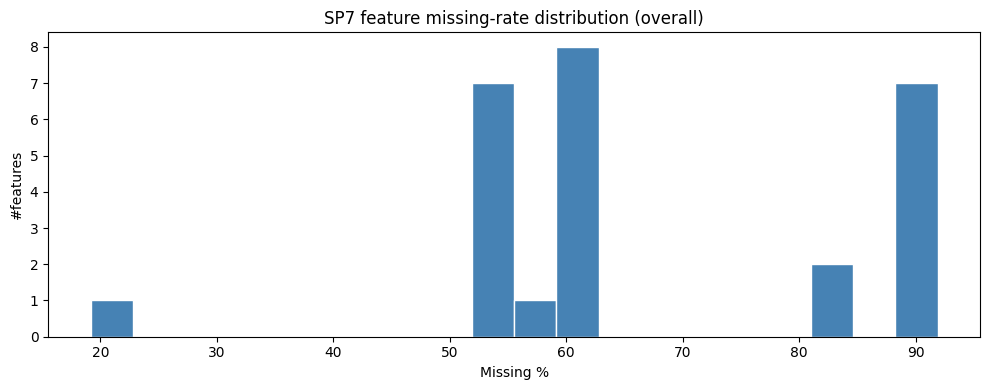

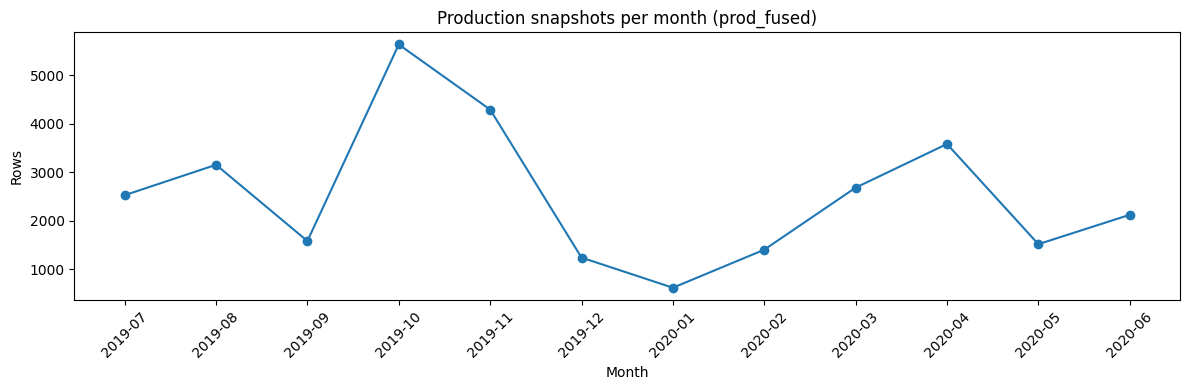

Step 3 complete. `prod` is now fused with SP7 features.


In [4]:
print("=== Step 3: Clean sp7_wide and merge into prod (as-of, backward) ===")

# Preconditions
if sp7_wide is None:
    raise RuntimeError("sp7_wide is None. Run Step 2B first.")
if prod is None:
    raise RuntimeError("prod is None. Run Step 2 first.")

# -------------------------
# 3.1 Clean sp7_wide
# -------------------------
# Keep only keys + numeric SP7 features.
# Drop metadata columns that cause duplication (employee, set_time, machine, etc.).
keys = ["VYP batch", "Part", "Timestamp"]

meta_drop_prefixes = (
    "SP7_employee",
    "SP7_set_time",
    "SP7_machine",
    "SP7_process",
)

candidate_cols = []
for c in sp7_wide.columns:
    if c in keys:
        continue
    if c.startswith(meta_drop_prefixes):
        continue
    # Keep only columns that look like setpoint features.
    # This avoids carrying through accidental text columns.
    if not c.startswith("SP7_"):
        continue
    candidate_cols.append(c)

sp7_feat = sp7_wide[keys + candidate_cols].copy()

# Coerce features to numeric
for c in candidate_cols:
    sp7_feat[c] = pd.to_numeric(sp7_feat[c], errors="coerce")

# Aggregate duplicates on the same (batch, part, timestamp)
sp7_feat = (
    sp7_feat.groupby(keys, as_index=False)
    .mean(numeric_only=True)
    .sort_values("Timestamp")
    .reset_index(drop=True)
)

print("sp7_feat shape:", sp7_feat.shape)
print("sp7_feat features:", len(candidate_cols))
print("sp7_feat time coverage:", sp7_feat["Timestamp"].min(), "->", sp7_feat["Timestamp"].max())

# -------------------------
# 3.2 Merge as-of (backward) into prod
# -------------------------
# We merge by Timestamp, and constrain by Part to prevent mixing yeast types.
# This is non-leaky because we only take the latest SP record at or before the snapshot time.

# IMPORTANT: merge_asof requires the 'on' key to be sorted globally.
# Sorting by ['Part', 'Timestamp'] breaks global monotonicity when we switch Part groups.
# Therefore we sort by ['Timestamp', 'Part'] on both sides.

prod_sorted = prod.sort_values(["Timestamp", "Part"]).reset_index(drop=True)
sp7_sorted = sp7_feat.sort_values(["Timestamp", "Part"]).reset_index(drop=True)

# merge_asof will match the latest SP7 row at or before the production snapshot,
# constrained within the same Part group.
prod_fused = pd.merge_asof(
    prod_sorted,
    sp7_sorted,
    on="Timestamp",
    by="Part",
    direction="backward",
)

print("prod_fused shape:", prod_fused.shape)
print("Added SP7 columns:", len([c for c in prod_fused.columns if c.startswith('SP7_')]))

# -------------------------
# 3.3 Missing-rate sanity checks
# -------------------------
sp7_cols = [c for c in prod_fused.columns if c.startswith("SP7_")]

# Overall missing rate
miss = prod_fused[sp7_cols].isna().mean().sort_values(ascending=False)
print("\nTop 10 missing-rate SP7 features (overall):")
display((miss.head(10) * 100).round(2).rename("missing_%"))

# Missing rate within downtime coverage window (Task 2 window)
combined_dt_str = downtime["Production Date"].astype(str).str.strip() + " " + downtime["Time"].astype(str).str.strip()
dt_start = pd.to_datetime(combined_dt_str, format="mixed", dayfirst=True, errors="coerce").dt.floor("min")
dt_dur = pd.to_numeric(downtime["Total Time Mins"], errors="coerce").fillna(0).clip(lower=0)
dt_end_incl = (dt_start + pd.to_timedelta(dt_dur, unit="m")) - pd.Timedelta(minutes=1)
valid = (~dt_start.isna()) & (~dt_end_incl.isna()) & (dt_end_incl >= dt_start)

if int(valid.sum()) > 0:
    s_min = dt_start[valid].min()
    e_max = dt_end_incl[valid].max()
    mask_dt_window = (prod_fused["Timestamp"] >= s_min) & (prod_fused["Timestamp"] <= e_max)
    miss_dt = prod_fused.loc[mask_dt_window, sp7_cols].isna().mean().sort_values(ascending=False)
    print("\nTop 10 missing-rate SP7 features (within downtime window):")
    display((miss_dt.head(10) * 100).round(2).rename("missing_%"))
    print("Downtime window rows:", int(mask_dt_window.sum()), "| window:", s_min, "->", e_max)

# -------------------------
# 3.4 Sanity charts (lightweight)
# -------------------------
# Chart A: missing rate distribution for SP7 columns
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist((miss * 100).values, bins=20, color="steelblue", edgecolor="white")
ax.set_title("SP7 feature missing-rate distribution (overall)")
ax.set_xlabel("Missing %")
ax.set_ylabel("#features")
plt.tight_layout()
plt.show()

# Chart B: rows per month (overall) and within downtime window
prod_fused["month"] = prod_fused["Timestamp"].dt.to_period("M").astype(str)
rows_per_month = prod_fused["month"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rows_per_month.index, rows_per_month.values, marker="o")
ax.set_title("Production snapshots per month (prod_fused)")
ax.set_xlabel("Month")
ax.set_ylabel("Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Expose prod_fused for later steps
prod = prod_fused
print("Step 3 complete. `prod` is now fused with SP7 features.")

---

## 4. Task 2 labeling (interval + warning) and where-machine

Mục tiêu:
- Chuẩn hoá SP7 duplicate columns (_x/_y) bằng cách coalesce về 1 cột
- Tạo 2 nhãn downtime theo đúng đề:
  - `y_dt_interval`: 1 nếu Timestamp nằm trong khoảng downtime event
  - `y_dt_warning`: 1 nếu Timestamp nằm trong warning window trước event (configurable)
- Tạo nhãn where-machine `y_where` từ `Line/Sub Line` (no_downtime vs Line_x_Sub_y)
- Lọc ra dataset Task 2 trong downtime coverage window và split theo thời gian
- In ra số positive trong train/val/test cho cả interval và warning để bạn kiểm soát


=== Step 4: Task 2 labeling (interval + warning) and where-machine ===
Remaining SP7 *_x/_y columns: 0
Warning window: , 1m] before start
Downtime window: 2020-05-04 13:30:00 -> 2020-07-02 04:29:00
Task 2 rows in window: 3579

Label prevalence (window):
  interval positives: 741
  warning positives : 569
  where classes     : 2

Split sanity (Task 2 window):


,split,rows,interval_pos,warning_pos
0,train,2505,489,379
1,val,536,85,70
2,test,538,167,120


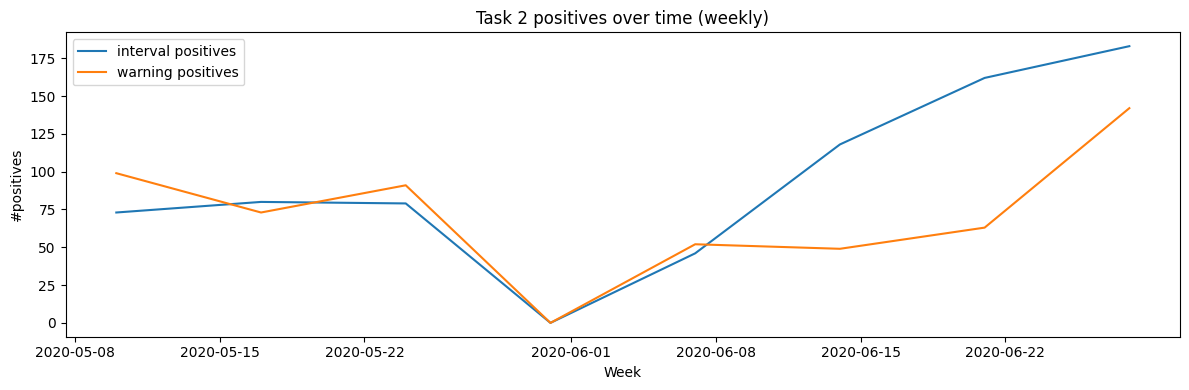

Step 4 complete. Task 2 data available as TASK2_DF and TASK2_SPLITS.


In [5]:
print("=== Step 4: Task 2 labeling (interval + warning) and where-machine ===")

# Preconditions
if prod is None:
    raise RuntimeError("prod is None. Run Step 2 and Step 3 first.")
if downtime is None:
    raise RuntimeError("downtime is None. Run Step 2 first.")

# -------------------------
# 4.1 Coalesce duplicate SP7 columns (clean schema)
# -------------------------
# Some SP7 columns may appear with suffixes like _x/_y due to earlier merges.
# We coalesce them: base = base.fillna(alt), then drop the alt columns.

def coalesce_suffix_columns(df: pd.DataFrame, suffixes=("_x", "_y")) -> pd.DataFrame:
    df = df.copy()

    # Map base -> list of columns that share the base name
    groups = {}
    for c in df.columns:
        for s in suffixes:
            if c.endswith(s):
                base = c[: -len(s)]
                groups.setdefault(base, []).append(c)
                break

    for base, cols in groups.items():
        if base not in df.columns:
            # Create base column if missing
            df[base] = np.nan

        # Coalesce values from suffix columns into base
        for c in sorted(cols):
            df[base] = df[base].fillna(df[c])

        # Drop suffix columns
        df = df.drop(columns=cols)

    return df

prod = coalesce_suffix_columns(prod)

# Confirm no SP7 *_x/_y remain
sp7_dups = [c for c in prod.columns if c.startswith("SP7_") and (c.endswith("_x") or c.endswith("_y"))]
print("Remaining SP7 *_x/_y columns:", len(sp7_dups))

# -------------------------
# 4.2 Build downtime intervals from event logs
# -------------------------
combined_dt_str = downtime["Production Date"].astype(str).str.strip() + " " + downtime["Time"].astype(str).str.strip()
dt_start = pd.to_datetime(combined_dt_str, format="mixed", dayfirst=True, errors="coerce").dt.floor("min")
dt_dur = pd.to_numeric(downtime["Total Time Mins"], errors="coerce").fillna(0).clip(lower=0)
dt_end_incl = (dt_start + pd.to_timedelta(dt_dur, unit="m")) - pd.Timedelta(minutes=1)

valid = (~dt_start.isna()) & (~dt_end_incl.isna()) & (dt_end_incl >= dt_start)
if int(valid.sum()) == 0:
    raise RuntimeError("No valid downtime intervals after parsing.")

# Config: warning window before downtime start
# Goal: improve early-warning signal. This window is BEFORE downtime start and does NOT include downtime minutes.
# You can tune these later. Empirically, warning too wide can add noisy positives.
# Start with a medium window to balance signal vs noise.
WARNING_START_MIN = 15  # minutes before event start
WARNING_END_MIN = 1     # minutes before event start (1 => last warning minute is start-1)
print(f"Warning window: [{WARNING_START_MIN}m, {WARNING_END_MIN}m] before start")

# Build minute-level sets for interval and warning labels
# Note: This is acceptable for this dataset size. If needed, we can optimize later.
interval_minutes = set()
warning_minutes = set()
minute_to_where = {}

for s, e, ln, sub in zip(
    dt_start[valid],
    dt_end_incl[valid],
    downtime.loc[valid, "Line"],
    downtime.loc[valid, "Sub Line"],
):
    # Interval minutes
    for ts in pd.date_range(s, e, freq="min"):
        interval_minutes.add(ts)

        # where-machine label (first label wins if collisions)
        try:
            ln_i = int(ln)
        except Exception:
            continue
        try:
            sub_i = int(sub) if sub is not None and str(sub) != "nan" else 0
        except Exception:
            sub_i = 0
        minute_to_where.setdefault(ts, f"Line_{ln_i}_Sub_{sub_i}")

    # Warning window minutes: [start-35, start-5]
    w_start = s - pd.Timedelta(minutes=int(WARNING_START_MIN))
    w_end = s - pd.Timedelta(minutes=int(WARNING_END_MIN))
    if w_end >= w_start:
        for ts in pd.date_range(w_start, w_end, freq="min"):
            warning_minutes.add(ts)

# -------------------------
# 4.3 Create Task 2 dataframe (restrict to downtime coverage window)
# -------------------------
# Task 2 should be trained/evaluated within the window where downtime logs exist.
window_start = dt_start[valid].min()
window_end = dt_end_incl[valid].max()

prod_dt = prod[(prod["Timestamp"] >= window_start) & (prod["Timestamp"] <= window_end)].copy()
prod_dt = prod_dt.sort_values("Timestamp").reset_index(drop=True)

print("Downtime window:", window_start, "->", window_end)
print("Task 2 rows in window:", len(prod_dt))

# Labels
prod_ts = pd.to_datetime(prod_dt["Timestamp"]).dt.floor("min")
prod_dt["y_dt_interval"] = prod_ts.isin(interval_minutes).astype(int).values
prod_dt["y_dt_warning"] = prod_ts.isin(warning_minutes).astype(int).values
prod_dt["y_where"] = np.array([minute_to_where.get(t, "no_downtime") for t in prod_ts], dtype=object)

print("\nLabel prevalence (window):")
print("  interval positives:", int(prod_dt["y_dt_interval"].sum()))
print("  warning positives :", int(prod_dt["y_dt_warning"].sum()))
print("  where classes     :", int(pd.Series(prod_dt["y_where"]).nunique()))

# -------------------------
# 4.4 Time split and sanity checks
# -------------------------

def time_split_indices(n: int, train_frac=0.7, val_frac=0.15):
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    n_train = max(1, min(n_train, n - 2))
    n_val = max(1, min(n_val, n - n_train - 1))
    tr = np.arange(0, n_train)
    va = np.arange(n_train, n_train + n_val)
    te = np.arange(n_train + n_val, n)
    return tr, va, te

tr_idx, va_idx, te_idx = time_split_indices(len(prod_dt), train_frac=0.7, val_frac=0.15)

split_summary = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "rows": [len(tr_idx), len(va_idx), len(te_idx)],
        "interval_pos": [
            int(prod_dt.loc[tr_idx, "y_dt_interval"].sum()),
            int(prod_dt.loc[va_idx, "y_dt_interval"].sum()),
            int(prod_dt.loc[te_idx, "y_dt_interval"].sum()),
        ],
        "warning_pos": [
            int(prod_dt.loc[tr_idx, "y_dt_warning"].sum()),
            int(prod_dt.loc[va_idx, "y_dt_warning"].sum()),
            int(prod_dt.loc[te_idx, "y_dt_warning"].sum()),
        ],
    }
)

print("\nSplit sanity (Task 2 window):")
display(split_summary)

# Quick chart: positives over time (weekly)
prod_dt["date"] = prod_dt["Timestamp"].dt.floor("D")
weekly = prod_dt.groupby(pd.Grouper(key="Timestamp", freq="W"))[["y_dt_interval", "y_dt_warning"]].sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly.index, weekly["y_dt_interval"], label="interval positives")
ax.plot(weekly.index, weekly["y_dt_warning"], label="warning positives")
ax.set_title("Task 2 positives over time (weekly)")
ax.set_xlabel("Week")
ax.set_ylabel("#positives")
ax.legend()
plt.tight_layout()
plt.show()

# Expose Task 2 dataset for later steps
TASK2_DF = prod_dt
TASK2_SPLITS = {"train": tr_idx, "val": va_idx, "test": te_idx}
print("Step 4 complete. Task 2 data available as TASK2_DF and TASK2_SPLITS.")

---

## 5. Task 1 preprocessing (feature sets for prescriptive SP recommendation)

Mục tiêu:
- Xác định rõ:
  - `sp_cols_main`: các cột SP trong MAIN (đuôi `SP`)
  - `sp_cols_sp7`: các cột SP7 sau fusion (`SP7_*`)
  - `pv_cols`: các cột sensor/PV (không phải SP)
- Chuẩn hoá kiểu dữ liệu numeric
- Chuẩn bị khung ràng buộc SP (min/max theo train) để phục vụ recommend

Chưa train model ở bước này.


In [6]:
# Step 5: define Task 1 prescriptive feature groups and SP constraints.
# Output of this step:
# - sp_cols_main / sp_cols_sp7 / pv_cols
# - sp_cols_canonical: the final controllable SP set (deduplicated)
# - sp_bounds: train-only bounds for each SP (per Part) to support recommendation later

if prod is None:
    raise RuntimeError("prod is None. Run Steps 2-3 first.")

# Target label available from MAIN
if "quality" not in prod.columns:
    raise KeyError("prod is missing 'quality' column.")

# 1) Main SP columns (controllable setpoints recorded in MAIN snapshots)
sp_cols_main = [c for c in prod.columns if c.endswith("SP")]

# 2) SP7 columns (setpoint logs) — added by Step 3 fusion
sp_cols_sp7 = [c for c in prod.columns if c.startswith("SP7_")]

# 3) Sensor/PV columns (process variables). We only keep numeric columns and exclude IDs/labels.
exclude_cols = {
    "quality",
    "Timestamp",
    "Set Time",
    "set time",
    "VYP batch",
    "Part",
    "month",
    "date",
    "y_dt_interval",
    "y_dt_warning",
    "y_where",
}

pv_cols = []
for c in prod.columns:
    if c in exclude_cols:
        continue
    if c.endswith("SP"):
        continue
    if c.startswith("SP7_"):
        continue
    if pd.api.types.is_numeric_dtype(prod[c]):
        pv_cols.append(c)

# Coerce SP columns to numeric (safe for both MAIN and SP7)
for c in sp_cols_main + sp_cols_sp7:
    prod[c] = pd.to_numeric(prod[c], errors="coerce")

print("=== Step 5: Task 1 prescriptive prep ===")
print("Main SP cols:", len(sp_cols_main))
print("SP7 cols     :", len(sp_cols_sp7))
print("PV cols      :", len(pv_cols))

# -------------------------
# 5.1 Choose a canonical controllable SP set (deduplicate MAIN vs SP7)
# -------------------------
# Rationale:
# - MAIN SP columns are the direct operator controls (usually the primary source).
# - SP7 provides additional setpoint logs, sometimes overlapping in meaning.
# We deduplicate by choosing the version with better coverage (lower missing rate) on TRAIN.

# Time split indices for Task 1 (full year). This is only used to compute constraints and coverage.
def time_split_indices(n: int, train_frac=0.7, val_frac=0.15):
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    n_train = max(1, min(n_train, n - 2))
    n_val = max(1, min(n_val, n - n_train - 1))
    tr = np.arange(0, n_train)
    va = np.arange(n_train, n_train + n_val)
    te = np.arange(n_train + n_val, n)
    return tr, va, te

prod_sorted = prod.sort_values("Timestamp").reset_index(drop=True)
tr_idx, va_idx, te_idx = time_split_indices(len(prod_sorted), train_frac=0.7, val_frac=0.15)
train_df = prod_sorted.iloc[tr_idx]

# Helper: normalize names to detect overlaps
import re

def _norm_name(s: str) -> str:
    s = str(s).lower()
    s = s.replace("sp7_", "")
    s = re.sub(r"[^a-z0-9]+", "", s)
    return s

main_norm = {c: _norm_name(c) for c in sp_cols_main}
sp7_norm = {c: _norm_name(c) for c in sp_cols_sp7}

# Build norm -> candidates mapping
norm_to_main = {}
for c, nrm in main_norm.items():
    norm_to_main.setdefault(nrm, []).append(c)

norm_to_sp7 = {}
for c, nrm in sp7_norm.items():
    norm_to_sp7.setdefault(nrm, []).append(c)

# Missing rate on train (lower is better)
train_missing = {}
for c in sp_cols_main + sp_cols_sp7:
    if c in train_df.columns:
        train_missing[c] = float(train_df[c].isna().mean())

sp_cols_canonical = []

# Prefer MAIN SPs by default; replace with SP7 only if MAIN is extremely sparse and SP7 is much better.
for nrm, main_cols in norm_to_main.items():
    # pick best MAIN candidate by missing
    best_main = sorted(main_cols, key=lambda x: train_missing.get(x, 1.0))[0]

    sp7_cols = norm_to_sp7.get(nrm, [])
    if not sp7_cols:
        sp_cols_canonical.append(best_main)
        continue

    best_sp7 = sorted(sp7_cols, key=lambda x: train_missing.get(x, 1.0))[0]

    miss_main = train_missing.get(best_main, 1.0)
    miss_sp7 = train_missing.get(best_sp7, 1.0)

    # Switch to SP7 only if it improves coverage substantially
    if (miss_main - miss_sp7) >= 0.20:
        sp_cols_canonical.append(best_sp7)
    else:
        sp_cols_canonical.append(best_main)

# Add SP7-only norms not present in MAIN
for nrm, sp7_cols in norm_to_sp7.items():
    if nrm in norm_to_main:
        continue
    best_sp7 = sorted(sp7_cols, key=lambda x: train_missing.get(x, 1.0))[0]
    sp_cols_canonical.append(best_sp7)

sp_cols_canonical = sorted(set(sp_cols_canonical))

print("\nCanonical controllable SP cols:", len(sp_cols_canonical))

# Show the best-covered SPs (train missing-rate)
sp_cov = pd.Series({c: train_missing.get(c, np.nan) for c in sp_cols_canonical}).sort_values()
print("Top 15 best-covered SPs (train missing-rate):")
display((sp_cov.head(15) * 100).round(2).rename("missing_%"))

# -------------------------
# 5.2 Build SP bounds (train-only) for prescriptive recommendation
# -------------------------
# We compute per-Part bounds to respect different yeast types.
# Use robust bounds via quantiles to avoid outliers.

bounds_rows = []
for part, g in train_df.groupby("Part"):
    for c in sp_cols_canonical:
        s = g[c]
        if s.notna().sum() < 10:
            continue
        q01 = float(s.quantile(0.01))
        q99 = float(s.quantile(0.99))
        bounds_rows.append(
            {
                "Part": part,
                "SP": c,
                "q01": q01,
                "q99": q99,
                "min": float(s.min()),
                "max": float(s.max()),
                "train_missing_%": float(s.isna().mean() * 100.0),
            }
        )

sp_bounds = pd.DataFrame(bounds_rows)
print("\nSP bounds table rows:", len(sp_bounds))

# Show a compact preview for a few SPs
if len(sp_bounds) > 0:
    display(sp_bounds.sort_values(["Part", "train_missing_%"]).head(20))

# Expose for later steps
TASK1_SPLITS = {"train": tr_idx, "val": va_idx, "test": te_idx}
TASK1_FEATURES = {
    "sp_cols_main": sp_cols_main,
    "sp_cols_sp7": sp_cols_sp7,
    "sp_cols_canonical": sp_cols_canonical,
    "pv_cols": pv_cols,
}

print("Step 5 complete. Outputs: TASK1_SPLITS, TASK1_FEATURES, sp_bounds")


=== Step 5: Task 1 prescriptive prep ===
Main SP cols: 7
SP7 cols     : 12
PV cols      : 23

Canonical controllable SP cols: 12
Top 15 best-covered SPs (train missing-rate):


FFTE Feed solids SP           0.00
FFTE Production solids SP     0.00
FFTE Steam pressure SP        0.00
TFE Out flow SP               0.00
TFE Vacuum pressure SP        0.00
TFE Steam pressure SP         0.00
TFE Production solids SP      0.00
SP7_vacuum_pressure_sp       22.45
SP7_production_solids_sp     58.32
SP7_steam_pressure_sp        58.50
SP7_feed_solids_sp           84.60
SP7_out_flow_sp              84.83
Name: missing_%, dtype: float64


SP bounds table rows: 36


,Part,SP,q01,q99,min,max,train_missing_%
0,Yeast - BRD,FFTE Feed solids SP,25.0000,50.0000,25.00,50.00,0.000000
1,Yeast - BRD,FFTE Production solids SP,39.0000,43.0000,39.00,43.00,0.000000
2,Yeast - BRD,FFTE Steam pressure SP,60.0000,159.8000,20.00,850.00,0.000000
8,Yeast - BRD,TFE Out flow SP,1240.0000,2991.8800,1240.00,3012.56,0.000000
9,Yeast - BRD,TFE Production solids SP,27.4900,78.0000,0.00,85.00,0.000000
10,Yeast - BRD,TFE Steam pressure SP,40.0000,135.0000,2.00,135.00,0.000000
11,Yeast - BRD,TFE Vacuum pressure SP,-89.0000,-36.4806,-89.00,-35.00,0.000000
7,Yeast - BRD,SP7_vacuum_pressure_sp,-89.0000,-37.3150,-89.00,-35.00,24.447044
5,Yeast - BRD,SP7_production_solids_sp,35.0000,72.7500,0.00,78.00,57.188430
6,Yeast - BRD,SP7_steam_pressure_sp,54.3142,158.8664,2.00,465.00,58.007231


Step 5 complete. Outputs: TASK1_SPLITS, TASK1_FEATURES, sp_bounds


---

## 6. Feature Engineering (minimal, no leakage)

Mục tiêu:
- Tạo một số feature time-series tối thiểu (diff/rolling) theo `Part`
- Tuyệt đối không dùng bfill cho lag (tránh future leakage)

(Làm sau khi bạn chốt được feature sets và constraints ở Step 5.)


In [7]:
print("=== Step 6: Feature engineering + task-ready matrices (no leakage) ===")

if prod is None:
    raise RuntimeError("prod is None. Run Steps 2-3 first.")
if "Timestamp" not in prod.columns:
    raise KeyError("prod missing Timestamp")
if "Part" not in prod.columns:
    raise KeyError("prod missing Part")

# We engineer time-series features grouped by Part (no leakage):
# - multiple lags (no backfill)
# - diffs
# - multiple rolling means
# + simple time features from Timestamp

LAGS = [1, 2, 3, 5, 10]
ROLL_WS = [3, 5, 10, 30, 60]

# Choose which columns to engineer:
# - PV columns (sensors) are the main dynamic signals
# - controllable SP columns (canonical) can also benefit from diff/rolling
# Note: SP7 columns are often sparse; we keep them raw (but still included as raw features).

pv_cols = TASK1_FEATURES["pv_cols"]
sp_cols_canonical = TASK1_FEATURES["sp_cols_canonical"]

fe_base_cols = sorted(set(pv_cols + sp_cols_canonical))
print("Base cols for FE:", len(fe_base_cols))

# Ensure numeric
for c in fe_base_cols:
    prod[c] = pd.to_numeric(prod[c], errors="coerce")

prod_sorted = prod.sort_values(["Timestamp", "Part"]).reset_index(drop=True)

# Time features (safe, no target leakage)
prod_sorted["ts_hour"] = prod_sorted["Timestamp"].dt.hour
prod_sorted["ts_dow"] = prod_sorted["Timestamp"].dt.dayofweek
prod_sorted["ts_month"] = prod_sorted["Timestamp"].dt.month

# Part encoding (helps models learn part-specific behavior)
_parts = sorted(prod_sorted["Part"].astype(str).unique().tolist())
PART_TO_CODE = {p: i for i, p in enumerate(_parts)}
prod_sorted["part_code"] = prod_sorted["Part"].astype(str).map(PART_TO_CODE).astype(int)

# Group by Part for time-series features

g = prod_sorted.groupby("Part", sort=False)

# Create engineered columns
for c in fe_base_cols:
    # lags
    for l in LAGS:
        prod_sorted[f"{c}__lag{l}"] = g[c].shift(l)

    # diffs
    prod_sorted[f"{c}__diff1"] = g[c].diff(1)
    prod_sorted[f"{c}__diff2"] = g[c].diff(2)

    # rolling means/std on raw series (uses past only)
    for w in ROLL_WS:
        prod_sorted[f"{c}__roll{w}"] = g[c].transform(lambda x, w=w: x.rolling(w, min_periods=1).mean())
        prod_sorted[f"{c}__std{w}"] = g[c].transform(lambda x, w=w: x.rolling(w, min_periods=2).std())

    # rolling mean/std of first-difference (captures trend/instability)
    d1 = g[c].diff(1)
    for w in [5, 10, 30]:
        prod_sorted[f"{c}__d1_roll{w}"] = d1.transform(lambda x, w=w: x.rolling(w, min_periods=1).mean())
        prod_sorted[f"{c}__d1_std{w}"] = d1.transform(lambda x, w=w: x.rolling(w, min_periods=2).std())

# Define final feature set for Task 1
sp7_cols = [c for c in prod_sorted.columns if c.startswith("SP7_")]

fe_cols = [
    c
    for c in prod_sorted.columns
    if ("__lag" in c) or c.endswith("__diff1") or c.endswith("__diff2") or ("__roll" in c)
]

time_cols = ["ts_hour", "ts_dow", "ts_month", "part_code"]

X1_cols = sorted(set(pv_cols + sp_cols_canonical + sp7_cols + fe_cols + time_cols))
print("Task 1 feature columns:", len(X1_cols))

# Task 1 labels
from sklearn.preprocessing import LabelEncoder
le_q = LabelEncoder()
y1_all = le_q.fit_transform(prod_sorted["quality"].astype(str))
print("Task 1 classes:", list(le_q.classes_))

# -------------------------
# Build Task 1 matrices using TASK1_SPLITS (train-only medians)
# -------------------------
tr1, va1, te1 = TASK1_SPLITS["train"], TASK1_SPLITS["val"], TASK1_SPLITS["test"]

X1_all = prod_sorted[X1_cols]

# Train-only median imputation
med1 = X1_all.iloc[tr1].median().to_dict()

X1_tr = X1_all.iloc[tr1].fillna(med1).fillna(0)
X1_va = X1_all.iloc[va1].fillna(med1).fillna(0)
X1_te = X1_all.iloc[te1].fillna(med1).fillna(0)

y1_tr = y1_all[tr1]
y1_va = y1_all[va1]
y1_te = y1_all[te1]

print("Task 1 matrices:")
print("  X1_tr:", X1_tr.shape, "| y1_tr:", y1_tr.shape)
print("  X1_va:", X1_va.shape, "| y1_va:", y1_va.shape)
print("  X1_te:", X1_te.shape, "| y1_te:", y1_te.shape)

# -------------------------
# Build Task 2 matrices (interval + warning + where) using TASK2_DF/TASK2_SPLITS
# -------------------------
if "TASK2_DF" not in globals():
    raise RuntimeError("TASK2_DF not found. Run Step 4 first.")

# For Task 2 we reuse the same feature columns as Task 1 (same sensors/SPs),
# but computed on the Task 2 window only.

prod2 = TASK2_DF.sort_values(["Timestamp", "Part"]).reset_index(drop=True)

# Ensure numeric for the same feature columns (safe)
for c in X1_cols:
    if c in prod2.columns:
        prod2[c] = pd.to_numeric(prod2[c], errors="coerce")

# If engineered columns are missing in TASK2_DF (because Step 4 was built before FE), rebuild them here.
# We compute FE on prod2 using the same base columns.

# Time features for Task 2 window
prod2["ts_hour"] = prod2["Timestamp"].dt.hour
prod2["ts_dow"] = prod2["Timestamp"].dt.dayofweek
prod2["ts_month"] = prod2["Timestamp"].dt.month

# Part encoding (reuse mapping from Task 1)
if "PART_TO_CODE" not in globals():
    _parts2 = sorted(prod2["Part"].astype(str).unique().tolist())
    PART_TO_CODE = {p: i for i, p in enumerate(_parts2)}
prod2["part_code"] = prod2["Part"].astype(str).map(PART_TO_CODE).fillna(-1).astype(int)

g2 = prod2.groupby("Part", sort=False)
for c in fe_base_cols:
    if c not in prod2.columns:
        continue

    for l in LAGS:
        prod2[f"{c}__lag{l}"] = g2[c].shift(l)

    prod2[f"{c}__diff1"] = g2[c].diff(1)
    prod2[f"{c}__diff2"] = g2[c].diff(2)

    for w in ROLL_WS:
        prod2[f"{c}__roll{w}"] = g2[c].transform(lambda x, w=w: x.rolling(w, min_periods=1).mean())
        prod2[f"{c}__std{w}"] = g2[c].transform(lambda x, w=w: x.rolling(w, min_periods=2).std())

    d1 = g2[c].diff(1)
    for w in [5, 10, 30]:
        prod2[f"{c}__d1_roll{w}"] = d1.transform(lambda x, w=w: x.rolling(w, min_periods=1).mean())
        prod2[f"{c}__d1_std{w}"] = d1.transform(lambda x, w=w: x.rolling(w, min_periods=2).std())

# Keep only feature columns that actually exist in prod2
X2_cols = [c for c in X1_cols if c in prod2.columns]

X2_all = prod2[X2_cols]
tr2, va2, te2 = TASK2_SPLITS["train"], TASK2_SPLITS["val"], TASK2_SPLITS["test"]

# Train-only median imputation for Task 2 window
med2 = X2_all.iloc[tr2].median().to_dict()
X2_tr = X2_all.iloc[tr2].fillna(med2).fillna(0)
X2_va = X2_all.iloc[va2].fillna(med2).fillna(0)
X2_te = X2_all.iloc[te2].fillna(med2).fillna(0)

# Labels

y2_int_tr = prod2.loc[tr2, "y_dt_interval"].astype(int).values
y2_int_va = prod2.loc[va2, "y_dt_interval"].astype(int).values
y2_int_te = prod2.loc[te2, "y_dt_interval"].astype(int).values

y2_warn_tr = prod2.loc[tr2, "y_dt_warning"].astype(int).values
y2_warn_va = prod2.loc[va2, "y_dt_warning"].astype(int).values
y2_warn_te = prod2.loc[te2, "y_dt_warning"].astype(int).values

from sklearn.preprocessing import LabelEncoder
le_where = LabelEncoder()
y2_where_all = le_where.fit_transform(prod2["y_where"].astype(str))

y2_where_tr = y2_where_all[tr2]
y2_where_va = y2_where_all[va2]
y2_where_te = y2_where_all[te2]

print("\nTask 2 matrices:")
print("  X2_tr:", X2_tr.shape, "| interval pos:", int(y2_int_tr.sum()), "| warning pos:", int(y2_warn_tr.sum()))
print("  X2_va:", X2_va.shape, "| interval pos:", int(y2_int_va.sum()), "| warning pos:", int(y2_warn_va.sum()))
print("  X2_te:", X2_te.shape, "| interval pos:", int(y2_int_te.sum()), "| warning pos:", int(y2_warn_te.sum()))
print("  where classes:", list(le_where.classes_))

# Expose for Step 7 training
TASK1_MATS = {"X_tr": X1_tr, "X_va": X1_va, "X_te": X1_te, "y_tr": y1_tr, "y_va": y1_va, "y_te": y1_te, "le_q": le_q, "cols": X1_cols, "medians": med1}
TASK2_MATS = {
    "X_tr": X2_tr,
    "X_va": X2_va,
    "X_te": X2_te,
    "y_int": {"tr": y2_int_tr, "va": y2_int_va, "te": y2_int_te},
    "y_warn": {"tr": y2_warn_tr, "va": y2_warn_va, "te": y2_warn_te},
    "y_where": {"tr": y2_where_tr, "va": y2_where_va, "te": y2_where_te},
    "le_where": le_where,
    "cols": X2_cols,
    "medians": med2,
}

print("\nStep 6 complete. Outputs: TASK1_MATS, TASK2_MATS")


=== Step 6: Feature engineering + task-ready matrices (no leakage) ===
Base cols for FE: 35
Task 1 feature columns: 431
Task 1 classes: ['good', 'high_bad', 'low_bad']
Task 1 matrices:
  X1_tr: (21262, 431) | y1_tr: (21262,)
  X1_va: (4556, 431) | y1_va: (4556,)
  X1_te: (4557, 431) | y1_te: (4557,)

Task 2 matrices:
  X2_tr: (2505, 431) | interval pos: 489 | warning pos: 379
  X2_va: (536, 431) | interval pos: 85 | warning pos: 70
  X2_te: (538, 431) | interval pos: 167 | warning pos: 120
  where classes: ['Line_6_Sub_0', 'no_downtime']

Step 6 complete. Outputs: TASK1_MATS, TASK2_MATS


---

## 7. Split (time-based)

- Task 1: split toàn bộ (1 năm) theo thời gian.
- Task 2: split **chỉ trong timeframe downtime log phủ** (May–Jun 2020) để train/val có đủ events.


=== Step 7: Pre-train dataset & split sanity (best effort) ===

--- Task 1 (Quality) ---
Split sizes: {'train': 21262, 'val': 4556, 'test': 4557}
  train time: 2019-07-01 07:59:00 -> 2020-03-17 17:20:00
  val   time: 2020-03-17 17:20:00 -> 2020-04-24 16:36:00
  test  time: 2020-04-24 16:37:00 -> 2020-06-26 03:27:00
Time order OK (Task 1 (Quality)): True
Label counts:
  train: {'good': 8825, 'high_bad': 11061, 'low_bad': 1376}
  val  : {'good': 2329, 'high_bad': 1905, 'low_bad': 322}
  test : {'good': 2148, 'high_bad': 1529, 'low_bad': 880}


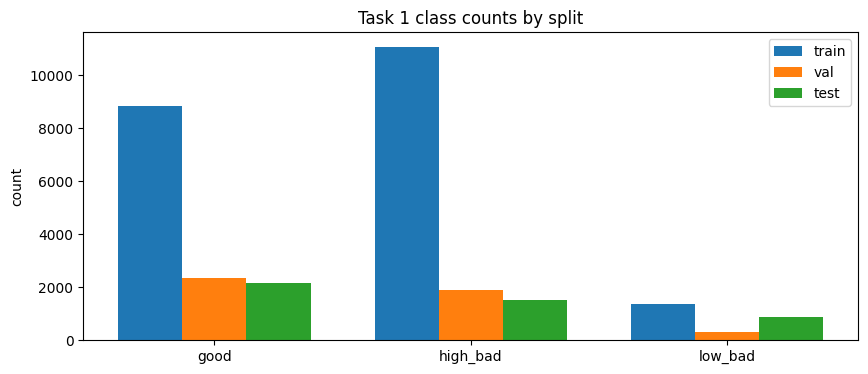

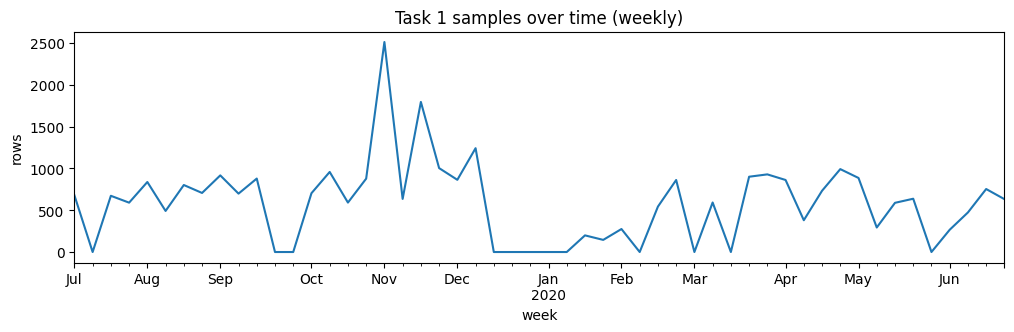


--- Task 2 (Downtime) ---
Split sizes: {'train': 2505, 'val': 536, 'test': 538}
  train time: 2020-05-04 14:01:00 -> 2020-06-16 07:40:00
  val   time: 2020-06-16 07:42:00 -> 2020-06-23 22:46:00
  test  time: 2020-06-23 22:49:00 -> 2020-06-26 03:27:00
Time order OK (Task 2 (Downtime)): True
Label counts:
  train: {'interval': {'pos': 489, 'neg': 2016}, 'warning': {'pos': 379, 'neg': 2126}, 'where_n_classes': 2}
  val  : {'interval': {'pos': 85, 'neg': 451}, 'warning': {'pos': 70, 'neg': 466}, 'where_n_classes': 2}
  test : {'interval': {'pos': 167, 'neg': 371}, 'warning': {'pos': 120, 'neg': 418}, 'where_n_classes': 2}

Where-machine distribution (decoded):
  train top:


no_downtime     2016
Line_6_Sub_0     489
Name: count, dtype: int64

  val   top:


no_downtime     451
Line_6_Sub_0     85
Name: count, dtype: int64

  test  top:


no_downtime     371
Line_6_Sub_0    167
Name: count, dtype: int64

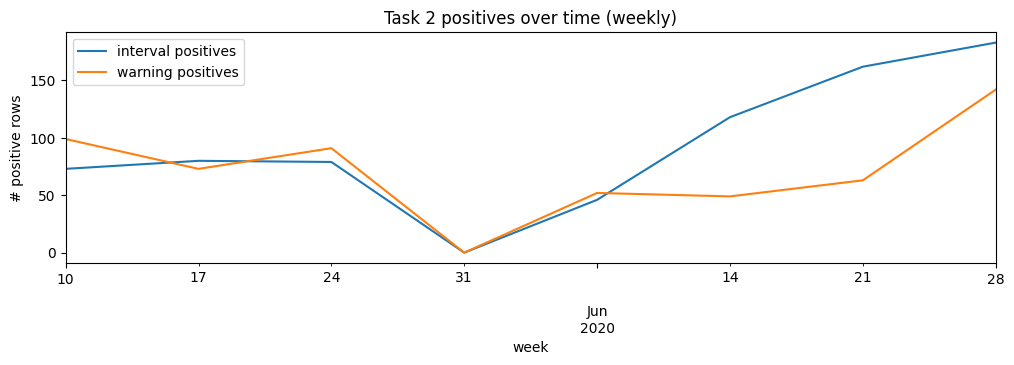


Step 7 complete.


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=== Step 7: Pre-train dataset & split sanity (best effort) ===")

# -------------------------
# Helpers
# -------------------------

def _time_range(ts: pd.Series):
    ts = pd.to_datetime(ts, errors="coerce")
    ts = ts.dropna()
    if len(ts) == 0:
        return None, None
    return ts.min(), ts.max()


def _assert_time_order(train_ts, val_ts, test_ts, name=""):
    # We allow touching boundaries but not overlaps.
    ok = True
    if train_ts[1] is not None and val_ts[0] is not None and train_ts[1] > val_ts[0]:
        ok = False
    if val_ts[1] is not None and test_ts[0] is not None and val_ts[1] > test_ts[0]:
        ok = False
    print(f"Time order OK ({name}):", ok)
    if not ok:
        print("  WARNING: split time ranges overlap. Check split indices construction.")


def _counts_from_encoded(y, classes):
    # y: array of ints
    s = pd.Series(y)
    out = {}
    for i, c in enumerate(classes):
        out[c] = int((s == i).sum())
    return out


def _print_split_report(title, df_for_time, splits, label_counts_fn=None):
    print(f"\n--- {title} ---")
    print("Split sizes:", {k: len(v) for k, v in splits.items()})

    # Time ranges
    for k in ["train", "val", "test"]:
        idx = splits[k]
        ts = df_for_time.loc[idx, "Timestamp"]
        t0, t1 = _time_range(ts)
        print(f"  {k:<5} time:", t0, "->", t1)

    # Check monotonic non-overlap
    tr_ts = _time_range(df_for_time.loc[splits["train"], "Timestamp"])
    va_ts = _time_range(df_for_time.loc[splits["val"], "Timestamp"])
    te_ts = _time_range(df_for_time.loc[splits["test"], "Timestamp"])
    _assert_time_order(tr_ts, va_ts, te_ts, name=title)

    # Label counts
    if label_counts_fn is not None:
        print("Label counts:")
        for k in ["train", "val", "test"]:
            print(f"  {k:<5}:", label_counts_fn(k))


# -------------------------
# Task 1 report
# -------------------------

# We prefer using the exact dataframe that indices refer to.
# Step 6 created prod_sorted (sorted by Timestamp,Part). If it's not in scope, rebuild.
if "prod_sorted" in globals():
    df1 = prod_sorted.reset_index(drop=True)
else:
    df1 = prod.sort_values(["Timestamp", "Part"]).reset_index(drop=True)

classes_q = list(TASK1_MATS["le_q"].classes_)

def _task1_label_counts(split_name):
    y_map = {
        "train": TASK1_MATS["y_tr"],
        "val": TASK1_MATS["y_va"],
        "test": TASK1_MATS["y_te"],
    }
    return _counts_from_encoded(y_map[split_name], classes_q)

_print_split_report(
    title="Task 1 (Quality)",
    df_for_time=df1,
    splits=TASK1_SPLITS,
    label_counts_fn=_task1_label_counts,
)

# Charts: class balance per split
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
labels = classes_q
x = np.arange(len(labels))
width = 0.25

cnt_tr = _task1_label_counts("train")
cnt_va = _task1_label_counts("val")
cnt_te = _task1_label_counts("test")

ax.bar(x - width, [cnt_tr[l] for l in labels], width, label="train")
ax.bar(x,         [cnt_va[l] for l in labels], width, label="val")
ax.bar(x + width, [cnt_te[l] for l in labels], width, label="test")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_title("Task 1 class counts by split")
ax.set_ylabel("count")
ax.legend()
plt.show()

# Timeline view: sample density by week (full df)
df1_ts = pd.to_datetime(df1["Timestamp"], errors="coerce").dt.floor("D")
weekly_all = df1_ts.value_counts().sort_index().resample("W").sum()

fig, ax = plt.subplots(1, 1, figsize=(12, 3))
weekly_all.plot(ax=ax)
ax.set_title("Task 1 samples over time (weekly)")
ax.set_xlabel("week")
ax.set_ylabel("rows")
plt.show()


# -------------------------
# Task 2 report
# -------------------------

# Task 2 indices refer to TASK2_DF (Step 4).
df2 = TASK2_DF.sort_values(["Timestamp", "Part"]).reset_index(drop=True)

# Binary label sanity (interval + warning)

def _bin_counts(y):
    y = np.asarray(y).astype(int)
    return {"pos": int((y == 1).sum()), "neg": int((y == 0).sum())}


def _task2_label_counts(split_name):
    y_int = TASK2_MATS["y_int"][{"train": "tr", "val": "va", "test": "te"}[split_name]]
    y_warn = TASK2_MATS["y_warn"][{"train": "tr", "val": "va", "test": "te"}[split_name]]
    y_where = TASK2_MATS["y_where"][{"train": "tr", "val": "va", "test": "te"}[split_name]]
    return {
        "interval": _bin_counts(y_int),
        "warning": _bin_counts(y_warn),
        "where_n_classes": int(pd.Series(y_where).nunique()),
    }

_print_split_report(
    title="Task 2 (Downtime)",
    df_for_time=df2,
    splits=TASK2_SPLITS,
    label_counts_fn=_task2_label_counts,
)

# Where-machine distribution (decoded) — show top labels per split
le_where = TASK2_MATS["le_where"]

print("\nWhere-machine distribution (decoded):")
for split_name, key in [("train", "tr"), ("val", "va"), ("test", "te")]:
    y_enc = TASK2_MATS["y_where"][key]
    y_dec = le_where.inverse_transform(np.asarray(y_enc))
    vc = pd.Series(y_dec).value_counts()
    print(f"  {split_name:<5} top:")
    display(vc.head(10))

# Charts: positives over time (weekly) for interval vs warning in Task 2 window
# We compute from df2 directly to visualize chronology.

ts2 = pd.to_datetime(df2["Timestamp"], errors="coerce").dt.floor("D")
interval_week = pd.Series(df2["y_dt_interval"].astype(int).values, index=ts2).resample("W").sum()
warning_week = pd.Series(df2["y_dt_warning"].astype(int).values, index=ts2).resample("W").sum()

fig, ax = plt.subplots(1, 1, figsize=(12, 3))
interval_week.plot(ax=ax, label="interval positives")
warning_week.plot(ax=ax, label="warning positives")
ax.set_title("Task 2 positives over time (weekly)")
ax.set_xlabel("week")
ax.set_ylabel("# positive rows")
ax.legend()
plt.show()

print("\nStep 7 complete.")


---

## 8. Train models (SOTA, 4 models, time-split)

Mục tiêu:
- Train **đủ 4 model**: **LightGBM / XGBoost / CatBoost / RandomForest**
- **Giữ time-split** (không CV shuffle) để tránh leakage
- Chọn model **tốt nhất trên validation** rồi mới sang Step 9 đánh giá test

Thực hiện:
- **Task 1 (Quality, 3-class)**: chọn best theo **macro-F1 (val)**
- **Task 2 (Downtime)**:
  - Binary **interval** và **warning**: chọn best theo **F1(positive) (val)** + **tune threshold**
  - **Where-machine**: chọn best theo **macro-F1 (val)**

Ghi chú:
- Nếu môi trường thiếu `xgboost` hoặc `catboost`, cell sẽ tự skip model đó.


In [9]:
from sklearn.metrics import f1_score
import numpy as np

print("=== Step 8: Train SOTA (4 models) — time-split, best-on-val ===")

# -------------------------
# Imports (some libs may be absent locally; Kaggle usually has them)
# -------------------------

import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
except Exception as e:
    XGBClassifier = None
    _xgb_import_err = repr(e)
else:
    _xgb_import_err = None

try:
    from catboost import CatBoostClassifier
except Exception as e:
    CatBoostClassifier = None
    _cat_import_err = repr(e)
else:
    _cat_import_err = None

print("Model availability:")
print("  LightGBM : OK")
print("  RF       : OK")
print("  XGBoost  :", "OK" if XGBClassifier is not None else f"MISSING ({_xgb_import_err})")
print("  CatBoost :", "OK" if CatBoostClassifier is not None else f"MISSING ({_cat_import_err})")


# -------------------------
# Shared helpers
# -------------------------

def _scale_pos_weight(y):
    y = np.asarray(y).astype(int)
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    return neg / max(pos, 1)


def _safe_predict_proba(model, X):
    p = model.predict_proba(X)
    p = np.asarray(p)
    if p.ndim == 2 and p.shape[1] >= 2:
        return p
    # If we only got positive prob, expand to 2 cols
    p = p.reshape(-1)
    return np.vstack([1 - p, p]).T


from sklearn.metrics import fbeta_score

def tune_threshold_from_proba(p_pos, y_val, beta=1.0, grid=np.linspace(0.01, 0.5, 100)):
    """Tune threshold on validation by maximizing F-beta of the positive class."""
    y_val = np.asarray(y_val).astype(int)
    if np.unique(y_val).size < 2:
        return 0.5, None

    best = (-1.0, 0.5)
    for t in grid:
        pred = (p_pos >= t).astype(int)
        s = fbeta_score(y_val, pred, beta=beta, zero_division=0)
        if s > best[0]:
            best = (float(s), float(t))

    return best[1], best[0]


# -------------------------
# Task 1: Quality (3-class)
# Strategy (to maximize performance): 2-stage classification to rescue low_bad.
#   Stage A: low_bad vs rest (probability + tuned threshold)
#   Stage B: good vs high_bad (for remaining samples)
# We tune the Stage A threshold on VAL to maximize 3-class macro-F1.
# -------------------------

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score

X1_tr = TASK1_MATS["X_tr"].values
X1_va = TASK1_MATS["X_va"].values

y1_tr = np.asarray(TASK1_MATS["y_tr"]).astype(int)
y1_va = np.asarray(TASK1_MATS["y_va"]).astype(int)

classes_q = list(TASK1_MATS["le_q"].classes_)
idx_good = int(classes_q.index("good"))
idx_high = int(classes_q.index("high_bad"))
idx_low = int(classes_q.index("low_bad"))

# Stage A labels: low_bad vs rest

yA_tr = (y1_tr == idx_low).astype(int)
yA_va = (y1_va == idx_low).astype(int)

spw_A = _scale_pos_weight(yA_tr)

# Candidates for Stage A (binary)
A_cands = []
A_cands.append((
    "lgbm",
    lgb.LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=127,
        min_child_samples=20,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=spw_A,
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
))
A_cands.append((
    "rf",
    RandomForestClassifier(
        n_estimators=1600,
        min_samples_leaf=2,
        n_jobs=-1,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
    ),
))
if XGBClassifier is not None:
    A_cands.append((
        "xgb",
        XGBClassifier(
            objective="binary:logistic",
            n_estimators=2000,
            learning_rate=0.03,
            max_depth=8,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            eval_metric="logloss",
            scale_pos_weight=spw_A,
        ),
    ))
if CatBoostClassifier is not None:
    A_cands.append((
        "cat",
        CatBoostClassifier(
            loss_function="Logloss",
            iterations=3500,
            learning_rate=0.03,
            depth=8,
            random_seed=RANDOM_STATE,
            verbose=False,
            auto_class_weights="Balanced",
        ),
    ))

print("\n--- Task 1 Stage A (low_bad vs rest): training candidates ---")
A_results = []
for name, model in A_cands:
    model.fit(X1_tr, yA_tr)
    p_va = _safe_predict_proba(model, X1_va)[:, 1]
    try:
        auc = float(roc_auc_score(yA_va, p_va)) if np.unique(yA_va).size > 1 else None
    except Exception:
        auc = None
    # Threshold tuned for recall-leaning low_bad detection
    thr, f2 = tune_threshold_from_proba(p_va, yA_va, beta=2.0)
    pred_va = (p_va >= thr).astype(int)
    f1p = float(f1_score(yA_va, pred_va, zero_division=0))
    A_results.append((name, f2 if f2 is not None else -1.0, f1p, float(thr), auc, model))

# Show table
try:
    import pandas as pd

    A_tbl = pd.DataFrame([
        {"model": n, "val_F2": s2, "val_F1": s1, "thr": t, "val_auc": a}
        for (n, s2, s1, t, a, _) in A_results
    ]).sort_values(["val_F2", "val_F1"], ascending=False).reset_index(drop=True)
    display(A_tbl)
except Exception:
    pass

# Prefer AUC first (more stable), then F2
best_A = sorted(A_results, key=lambda x: ((x[4] if x[4] is not None else -1.0), x[1], x[2]), reverse=True)[0]
TASK1_STAGEA = {"name": best_A[0], "thr": best_A[3], "model": best_A[5], "val_F2": float(best_A[1]), "val_F1": float(best_A[2]), "val_auc": best_A[4]}
print("Task 1 Stage A BEST:", TASK1_STAGEA["name"], "| thr=", TASK1_STAGEA["thr"], "| val AUC=", TASK1_STAGEA.get("val_auc"), "| val F2=", TASK1_STAGEA["val_F2"], "| val F1=", TASK1_STAGEA["val_F1"])

# Stage B training set: only good/high_bad
mask_B_tr = (y1_tr != idx_low)
mask_B_va = (y1_va != idx_low)

X1B_tr = X1_tr[mask_B_tr]
y1B_tr = y1_tr[mask_B_tr]
X1B_va = X1_va[mask_B_va]
y1B_va = y1_va[mask_B_va]

# Remap to {good=0, high=1}
map_B = {idx_good: 0, idx_high: 1}
yB_tr = np.asarray([map_B[int(y)] for y in y1B_tr], dtype=int)
yB_va = np.asarray([map_B[int(y)] for y in y1B_va], dtype=int)

spw_B = _scale_pos_weight(yB_tr)

B_cands = []
B_cands.append((
    "lgbm",
    lgb.LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=127,
        min_child_samples=20,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=spw_B,
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
))
B_cands.append((
    "rf",
    RandomForestClassifier(
        n_estimators=1600,
        min_samples_leaf=2,
        n_jobs=-1,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
    ),
))
if XGBClassifier is not None:
    B_cands.append((
        "xgb",
        XGBClassifier(
            objective="binary:logistic",
            n_estimators=2000,
            learning_rate=0.03,
            max_depth=8,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            eval_metric="logloss",
            scale_pos_weight=spw_B,
        ),
    ))
if CatBoostClassifier is not None:
    B_cands.append((
        "cat",
        CatBoostClassifier(
            loss_function="Logloss",
            iterations=3500,
            learning_rate=0.03,
            depth=8,
            random_seed=RANDOM_STATE,
            verbose=False,
            auto_class_weights="Balanced",
        ),
    ))

print("\n--- Task 1 Stage B (good vs high_bad): training candidates ---")
B_results = []
for name, model in B_cands:
    model.fit(X1B_tr, yB_tr)
    pred_va = np.asarray(model.predict(X1B_va)).astype(int).reshape(-1)
    f1p = float(f1_score(yB_va, pred_va, zero_division=0))
    B_results.append((name, f1p, model))

try:
    import pandas as pd

    B_tbl = pd.DataFrame([
        {"model": n, "val_F1(high_bad)": s}
        for (n, s, _) in B_results
    ]).sort_values("val_F1(high_bad)", ascending=False).reset_index(drop=True)
    display(B_tbl)
except Exception:
    pass

best_B = sorted(B_results, key=lambda x: x[1], reverse=True)[0]
TASK1_STAGEB = {"name": best_B[0], "val_f1": float(best_B[1]), "model": best_B[2]}
print("Task 1 Stage B BEST:", TASK1_STAGEB["name"], "| val F1(high_bad)=", TASK1_STAGEB["val_f1"])

# Tune Stage A threshold to maximize overall 3-class macro-F1 on VAL
pA_va = _safe_predict_proba(TASK1_STAGEA["model"], X1_va)[:, 1]

thr_grid = np.linspace(0.01, 0.9, 90)

# We tune threshold with a constraint to actually predict low_bad.
# Otherwise macro-F1 tuning can pick a threshold that almost never fires low_bad.

target_low_recall = 0.20  # on VAL (aggressive to force low_bad detection)

best = (-1.0, None, None)  # (macroF1, thr, low_recall)
best_feasible = (-1.0, None, None)

for thr in thr_grid:
    is_low = pA_va >= thr

    # Stage B prediction for non-low samples
    pred_full = np.full_like(y1_va, fill_value=idx_high, dtype=int)  # init

    non_low_idx = np.where(~is_low)[0]
    if len(non_low_idx) > 0:
        pred_B = np.asarray(TASK1_STAGEB["model"].predict(X1_va[non_low_idx])).astype(int).reshape(-1)
        pred_full[non_low_idx] = np.where(pred_B == 0, idx_good, idx_high)

    pred_full[is_low] = idx_low

    f1m = float(f1_score(y1_va, pred_full, average="macro", zero_division=0))

    # low_bad recall on VAL
    low_mask = (y1_va == idx_low)
    low_recall = float(((pred_full[low_mask] == idx_low).sum()) / max(int(low_mask.sum()), 1))

    if f1m > best[0]:
        best = (f1m, float(thr), low_recall)

    if low_recall >= target_low_recall and f1m > best_feasible[0]:
        best_feasible = (f1m, float(thr), low_recall)

# Prefer feasible solution if it exists.
# If infeasible, pick the threshold that maximizes low_bad recall first, then macro-F1.
if best_feasible[1] is not None:
    chosen = best_feasible
else:
    chosen = best  # default
    # fallback: maximize low_bad recall
    # (we reconstruct by scanning again quickly)
    best_lr = (-1.0, None, None)
    for thr in thr_grid:
        is_low = pA_va >= thr
        pred_full = np.full_like(y1_va, fill_value=idx_high, dtype=int)
        non_low_idx = np.where(~is_low)[0]
        if len(non_low_idx) > 0:
            pred_B = np.asarray(TASK1_STAGEB["model"].predict(X1_va[non_low_idx])).astype(int).reshape(-1)
            pred_full[non_low_idx] = np.where(pred_B == 0, idx_good, idx_high)
        pred_full[is_low] = idx_low
        f1m = float(f1_score(y1_va, pred_full, average="macro", zero_division=0))
        low_mask = (y1_va == idx_low)
        low_recall = float(((pred_full[low_mask] == idx_low).sum()) / max(int(low_mask.sum()), 1))
        if (low_recall > best_lr[2] if best_lr[1] is not None else True) or (low_recall == best_lr[2] and f1m > best_lr[0]):
            best_lr = (f1m, float(thr), low_recall)
    if best_lr[1] is not None:
        chosen = best_lr

TASK1_TWO_STAGE = {
    "stageA": TASK1_STAGEA,
    "stageB": TASK1_STAGEB,
    "thr_macro": chosen[1],
    "val_macro_f1": chosen[0],
    "val_lowbad_recall": chosen[2],
    "val_lowbad_recall_target": target_low_recall,
}

print("\nTask 1 TWO-STAGE selected:")
print("  StageA:", TASK1_STAGEA["name"], "thr(F2)=", TASK1_STAGEA["thr"], "| val AUC=", TASK1_STAGEA.get("val_auc"))
print("  StageB:", TASK1_STAGEB["name"])
print(
    "  Final threshold (macro-F1 tuned w/ low_bad recall constraint):",
    TASK1_TWO_STAGE["thr_macro"],
    "| val macro-F1=", TASK1_TWO_STAGE["val_macro_f1"],
    "| val low_bad recall=", TASK1_TWO_STAGE["val_lowbad_recall"],
)

# For downstream cells: keep TASK1_BEST as the 2-stage system
TASK1_BEST = {"name": "two_stage", "val_macro_f1": float(TASK1_TWO_STAGE["val_macro_f1"]), "model": None}


# -------------------------
# Task 2: Downtime binary (interval + warning)
# Select best by VAL F1(positive) with tuned threshold
# -------------------------

X2_tr = TASK2_MATS["X_tr"].values
X2_va = TASK2_MATS["X_va"].values

y2_int_tr = TASK2_MATS["y_int"]["tr"]
y2_int_va = TASK2_MATS["y_int"]["va"]

y2_warn_tr = TASK2_MATS["y_warn"]["tr"]
y2_warn_va = TASK2_MATS["y_warn"]["va"]


def _train_binary_family(y_tr, y_va, label=""):
    spw = _scale_pos_weight(y_tr)
    cands = []

    cands.append((
        "lgbm",
        lgb.LGBMClassifier(
            n_estimators=1500,
            learning_rate=0.03,
            num_leaves=127,
            min_child_samples=20,
            subsample=0.9,
            colsample_bytree=0.9,
            scale_pos_weight=spw,
            random_state=RANDOM_STATE,
            verbose=-1,
        ),
    ))

    cands.append((
        "rf",
        RandomForestClassifier(
            n_estimators=1200,
            min_samples_leaf=2,
            n_jobs=-1,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ))

    if XGBClassifier is not None:
        cands.append((
            "xgb",
            XGBClassifier(
                objective="binary:logistic",
                n_estimators=1500,
                learning_rate=0.03,
                max_depth=8,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_lambda=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                eval_metric="logloss",
                scale_pos_weight=spw,
            ),
        ))

    if CatBoostClassifier is not None:
        cands.append((
            "cat",
            CatBoostClassifier(
                loss_function="Logloss",
                iterations=2500,
                learning_rate=0.03,
                depth=8,
                random_seed=RANDOM_STATE,
                verbose=False,
                auto_class_weights="Balanced",
            ),
        ))

    print(f"\n--- Task 2 ({label}): training candidates ---")
    results = []
    for name, model in cands:
        model.fit(X2_tr, y_tr)
        p_va = _safe_predict_proba(model, X2_va)[:, 1]

        # Use F-beta to trade precision/recall (beta>1 favors recall)
        beta = 2.0 if label == "interval" else 1.0
        thr, _ = tune_threshold_from_proba(p_va, y_va, beta=beta)

        pred_va = (p_va >= thr).astype(int)
        f1p = float(f1_score(y_va, pred_va, zero_division=0))

        # Validation AUC (more stable selection signal for warning)
        try:
            auc = float(roc_auc_score(y_va, p_va)) if np.unique(y_va).size > 1 else None
        except Exception:
            auc = None

        # Store as: (name, f1_pos, thr, auc, model)
        results.append((name, f1p, float(thr), auc, model))

        # Pretty summary table
    try:
        import pandas as pd

        t2_tbl = pd.DataFrame(
            [
                {"model": n, "val_f1_pos": s, "thr": t, "val_auc": a}
                for (n, s, t, a, _) in results
            ]
        )
        # Put None AUC at the bottom
        t2_tbl["val_auc"] = pd.to_numeric(t2_tbl["val_auc"], errors="coerce")
        t2_tbl = t2_tbl.sort_values(["val_auc", "val_f1_pos"], ascending=False).reset_index(drop=True)
        display(t2_tbl)
    except Exception:
        def _key(x):
            # x = (name, f1, thr, auc, model)
            auc = x[3]
            auc_key = auc if auc is not None else -1.0
            return (auc_key, x[1])
        for n, s, t, a, _ in sorted(results, key=_key, reverse=True):
            print(f"  {n:<4} val AUC = {a} | val F1+ = {s:.4f} @ thr={t:.3f}")

    def _auc_key(x):
        auc = x[3]
        return auc if auc is not None else -1.0

    # For warning: prioritize AUC (more stable), then F1+. For interval: prioritize F1+.
    if label == "warning":
        best = sorted(results, key=lambda x: (_auc_key(x), x[1]), reverse=True)[0]
    else:
        best = sorted(results, key=lambda x: x[1], reverse=True)[0]

    return {"name": best[0], "val_f1_pos": best[1], "thr": best[2], "val_auc": best[3], "model": best[4]}

# For interval, we favor recall (F2). For warning, F1 is usually a better trade-off.
TASK2_BEST_INTERVAL = _train_binary_family(y2_int_tr, y2_int_va, label="interval")
TASK2_BEST_WARNING = _train_binary_family(y2_warn_tr, y2_warn_va, label="warning")

print("\nTask 2 BEST interval:", TASK2_BEST_INTERVAL["name"], "| val F1+=", TASK2_BEST_INTERVAL["val_f1_pos"], "| thr=", TASK2_BEST_INTERVAL["thr"])
print("Task 2 BEST warning :", TASK2_BEST_WARNING["name"], "| val F1+=", TASK2_BEST_WARNING["val_f1_pos"], "| thr=", TASK2_BEST_WARNING["thr"])


# -------------------------
# Task 2: Where-machine
# Select best by VAL macro-F1
# -------------------------

yw_tr = TASK2_MATS["y_where"]["tr"]
yw_va = TASK2_MATS["y_where"]["va"]

n_where = int(len(TASK2_MATS["le_where"].classes_))

cands_where = []

# LGBM: binary vs multiclass
if n_where == 2:
    cands_where.append((
        "lgbm",
        lgb.LGBMClassifier(
            n_estimators=1200,
            learning_rate=0.03,
            num_leaves=127,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            verbose=-1,
        ),
    ))
else:
    cands_where.append((
        "lgbm",
        lgb.LGBMClassifier(
            objective="multiclass",
            num_class=n_where,
            n_estimators=1200,
            learning_rate=0.03,
            num_leaves=127,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            verbose=-1,
        ),
    ))

cands_where.append((
    "rf",
    RandomForestClassifier(
        n_estimators=1200,
        min_samples_leaf=2,
        n_jobs=-1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
))

if XGBClassifier is not None:
    if n_where == 2:
        cands_where.append((
            "xgb",
            XGBClassifier(
                objective="binary:logistic",
                n_estimators=1500,
                learning_rate=0.03,
                max_depth=8,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                eval_metric="logloss",
            ),
        ))
    else:
        cands_where.append((
            "xgb",
            XGBClassifier(
                objective="multi:softprob",
                num_class=n_where,
                n_estimators=1500,
                learning_rate=0.03,
                max_depth=8,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                eval_metric="mlogloss",
            ),
        ))

if CatBoostClassifier is not None:
    if n_where == 2:
        cands_where.append((
            "cat",
            CatBoostClassifier(
                loss_function="Logloss",
                iterations=2500,
                learning_rate=0.03,
                depth=8,
                random_seed=RANDOM_STATE,
                verbose=False,
                auto_class_weights="Balanced",
            ),
        ))
    else:
        cands_where.append((
            "cat",
            CatBoostClassifier(
                loss_function="MultiClass",
                iterations=2500,
                learning_rate=0.03,
                depth=8,
                random_seed=RANDOM_STATE,
                verbose=False,
            ),
        ))

print("\n--- Task 2 (where-machine): training candidates ---")
where_results = []
for name, model in cands_where:
    model.fit(X2_tr, yw_tr)
    pred_va = np.asarray(model.predict(X2_va)).astype(int).reshape(-1)
    f1_macro = f1_score(yw_va, pred_va, average="macro", zero_division=0)
    where_results.append((name, float(f1_macro), model))

# Pretty summary table
try:
    import pandas as pd

    where_tbl = pd.DataFrame(
        [{"model": n, "val_macro_f1": s} for (n, s, _) in where_results]
    ).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
    display(where_tbl)
except Exception:
    for n, s, _ in sorted(where_results, key=lambda x: x[1], reverse=True):
        print(f"  {n:<4} val macro-F1 = {s:.4f}")

best_where = sorted(where_results, key=lambda x: x[1], reverse=True)[0]
TASK2_BEST_WHERE = {"name": best_where[0], "val_macro_f1": best_where[1], "model": best_where[2]}
print("Task 2 BEST where-machine:", TASK2_BEST_WHERE["name"], "| val macro-F1=", TASK2_BEST_WHERE["val_macro_f1"])

# Backward-compatible aliases used by Step 9 / Step 12
# Task 1 is now 2-stage, so m_quality is not used for inference.
m_quality = None

m_dt_interval = TASK2_BEST_INTERVAL["model"]
thr_interval = float(TASK2_BEST_INTERVAL["thr"])

m_dt_warning = TASK2_BEST_WARNING["model"]
thr_warning = float(TASK2_BEST_WARNING["thr"])

m_where = TASK2_BEST_WHERE["model"]

print("\nStep 8 complete. Outputs: TASK1_BEST, TASK2_BEST_INTERVAL, TASK2_BEST_WARNING, TASK2_BEST_WHERE")


=== Step 8: Train SOTA (4 models) — time-split, best-on-val ===
Model availability:
  LightGBM : OK
  RF       : OK
  XGBoost  : OK
  CatBoost : OK
Task 1 class weights: {'good': 0.803, 'high_bad': 0.641, 'low_bad': 5.151}

--- Task 1 (quality): training candidates ---


,model,val_macro_f1
0,rf,0.526285
1,cat,0.521824
2,lgbm,0.518403
3,xgb,0.516929


Task 1 BEST: rf | val macro-F1= 0.5262845306064733

--- Task 2 (interval): training candidates ---


,model,val_f1_pos,thr
0,cat,0.626609,0.010000
1,rf,0.607930,0.163434
2,lgbm,0.598802,0.039697
3,xgb,0.592593,0.010000



--- Task 2 (warning): training candidates ---


,model,val_f1_pos,thr
0,cat,0.683544,0.039697
1,xgb,0.666667,0.010000
2,lgbm,0.661871,0.010000
3,rf,0.504425,0.108990



Task 2 BEST interval: cat | val F1+= 0.6266094420600858 | thr= 0.01
Task 2 BEST warning : cat | val F1+= 0.6835443037974683 | thr= 0.039696969696969696

--- Task 2 (where-machine): training candidates ---


,model,val_macro_f1
0,cat,0.792150
1,rf,0.788022
2,lgbm,0.770052
3,xgb,0.770052


Task 2 BEST where-machine: cat | val macro-F1= 0.7921502368224247

Step 8 complete. Outputs: TASK1_BEST, TASK2_BEST_INTERVAL, TASK2_BEST_WARNING, TASK2_BEST_WHERE


---

## 9. Evaluation (test set)

Đánh giá trên **test split** bằng các model đã chọn best ở Step 8:
- **Task 1 (Quality)**: classification report + confusion matrix
- **Task 2 (Downtime)**:
  - Binary **interval** và **warning**: report + confusion matrix + ROC-AUC (nếu tính được)
  - **Where-machine**: classification report


In [10]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
import numpy as np

print("\n=== Step 9: Evaluation (BEST models on test) ===")

# Helpful context
try:
    print("\nSelected models (from Step 8):")
    print("  Task 1 quality:", TASK1_BEST["name"], "| val macro-F1=", TASK1_BEST["val_macro_f1"])
    print("  Task 2 interval:", TASK2_BEST_INTERVAL["name"], "| val F1+=", TASK2_BEST_INTERVAL["val_f1_pos"], "| thr=", float(thr_interval))
    print("  Task 2 warning :", TASK2_BEST_WARNING["name"], "| val F1+=", TASK2_BEST_WARNING["val_f1_pos"], "| thr=", float(thr_warning))
    print("  Task 2 where   :", TASK2_BEST_WHERE["name"], "| val macro-F1=", TASK2_BEST_WHERE["val_macro_f1"])
except Exception:
    pass

# -------------------------
# Task 1: Quality (2-stage)
# -------------------------
print("\n=== Task 1 — Quality (test) ===")

X1_te = TASK1_MATS["X_te"].values
y1_te = np.asarray(TASK1_MATS["y_te"]).astype(int)

# Stage A probability on test
pA_te = _safe_predict_proba(TASK1_TWO_STAGE["stageA"]["model"], X1_te)[:, 1]
thr_final = float(TASK1_TWO_STAGE["thr_macro"])

is_low = pA_te >= thr_final
q_pred = np.full_like(y1_te, fill_value=idx_high, dtype=int)

# Stage B predictions for non-low
non_low_idx = np.where(~is_low)[0]
if len(non_low_idx) > 0:
    pred_B = np.asarray(TASK1_TWO_STAGE["stageB"]["model"].predict(X1_te[non_low_idx])).astype(int).reshape(-1)
    q_pred[non_low_idx] = np.where(pred_B == 0, idx_good, idx_high)

# Low
q_pred[is_low] = idx_low

print("2-stage threshold:", thr_final)
print(classification_report(y1_te, q_pred, target_names=TASK1_MATS["le_q"].classes_, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y1_te, q_pred))

# -------------------------
# Task 2: Downtime binary (interval vs warning)
# -------------------------
X2_te = TASK2_MATS["X_te"]

print("\n=== Task 2 — Downtime (interval label, test) ===")
p_int = np.asarray(m_dt_interval.predict_proba(X2_te.values))[:, 1]
pred_int = (p_int >= float(thr_interval)).astype(int)
print("Threshold:", float(thr_interval))
print(classification_report(TASK2_MATS["y_int"]["te"], pred_int, target_names=["no_downtime", "downtime"], zero_division=0))
print("Confusion matrix:\n", confusion_matrix(TASK2_MATS["y_int"]["te"], pred_int))
try:
    print("ROC-AUC:", roc_auc_score(TASK2_MATS["y_int"]["te"], p_int))
except Exception:
    pass

print("\n=== Task 2 — Downtime (warning label, test) ===")
p_warn = np.asarray(m_dt_warning.predict_proba(X2_te.values))[:, 1]
pred_warn = (p_warn >= float(thr_warning)).astype(int)
print("Threshold:", float(thr_warning))
print(classification_report(TASK2_MATS["y_warn"]["te"], pred_warn, target_names=["no_downtime", "downtime"], zero_division=0))
print("Confusion matrix:\n", confusion_matrix(TASK2_MATS["y_warn"]["te"], pred_warn))
try:
    print("ROC-AUC:", roc_auc_score(TASK2_MATS["y_warn"]["te"], p_warn))
except Exception:
    pass

# -------------------------
# Task 2: Where-machine
# -------------------------
print("\n=== Task 2 — Where-machine (test) ===")
pred_w = np.asarray(m_where.predict(X2_te.values)).astype(int).reshape(-1)
print(classification_report(TASK2_MATS["y_where"]["te"], pred_w, target_names=TASK2_MATS["le_where"].classes_, zero_division=0))



=== Step 9: Evaluation (BEST models on test) ===

Selected models (from Step 8):
  Task 1 quality: rf | val macro-F1= 0.5262845306064733
  Task 2 interval: cat | val F1+= 0.6266094420600858 | thr= 0.01
  Task 2 warning : cat | val F1+= 0.6835443037974683 | thr= 0.039696969696969696
  Task 2 where   : cat | val macro-F1= 0.7921502368224247

=== Task 1 — Quality (test) ===
              precision    recall  f1-score   support

        good       0.46      0.38      0.42      2148
    high_bad       0.34      0.63      0.44      1529
     low_bad       0.00      0.00      0.00       880

    accuracy                           0.39      4557
   macro avg       0.27      0.34      0.29      4557
weighted avg       0.33      0.39      0.35      4557

Confusion matrix:
 [[ 815 1333    0]
 [ 565  964    0]
 [ 373  507    0]]

=== Task 2 — Downtime (interval label, test) ===
Threshold: 0.01
              precision    recall  f1-score   support

 no_downtime       0.84      0.87      0.85      

---

## 10. Model Comparison (optional)

Ở bản stepwise này, bước này chỉ là placeholder.
Khi bạn OK pipeline, mình mới thêm benchmark (XGB/LGB/RF/CatBoost).


In [11]:
import pandas as pd

print("=== Step 10: Model Comparison (val metrics) ===")

rows = [
    {
        "task": "Task 1 (quality)",
        "selected_model": TASK1_BEST["name"],
        "val_metric": "macro-F1",
        "val_score": float(TASK1_BEST["val_macro_f1"]),
        "threshold": None,
    },
    {
        "task": "Task 2 (downtime interval)",
        "selected_model": TASK2_BEST_INTERVAL["name"],
        "val_metric": "F1(positive)",
        "val_score": float(TASK2_BEST_INTERVAL["val_f1_pos"]),
        "threshold": float(TASK2_BEST_INTERVAL["thr"]),
    },
    {
        "task": "Task 2 (downtime warning)",
        "selected_model": TASK2_BEST_WARNING["name"],
        "val_metric": "F1(positive)",
        "val_score": float(TASK2_BEST_WARNING["val_f1_pos"]),
        "threshold": float(TASK2_BEST_WARNING["thr"]),
    },
    {
        "task": "Task 2 (where-machine)",
        "selected_model": TASK2_BEST_WHERE["name"],
        "val_metric": "macro-F1",
        "val_score": float(TASK2_BEST_WHERE["val_macro_f1"]),
        "threshold": None,
    },
]

summary = pd.DataFrame(rows).sort_values(["task"]).reset_index(drop=True)
display(summary)

print("\nNote: full candidate tables are printed in Step 8.")


=== Step 10: Model Comparison (val metrics) ===


,task,selected_model,val_metric,val_score,threshold
0,Task 1 (quality),rf,macro-F1,0.526285,NaN
1,Task 2 (downtime interval),cat,F1(positive),0.626609,0.010000
2,Task 2 (downtime warning),cat,F1(positive),0.683544,0.039697
3,Task 2 (where-machine),cat,macro-F1,0.792150,NaN



Note: full candidate tables are printed in Step 8.


---

## 11. Feature Importance (optional)

Placeholder: LightGBM feature importance có thể thêm sau khi bạn chốt `TASK1_MATS["cols"]` (feature set ổn định).


=== Step 11: Feature Importance (best models) ===

Task 1 — feature importance (best=rf)


,feature,importance
0,ts_month,0.011910
1,TFE Production solids SP__roll30,0.011359
2,TFE Out flow SP,0.009674
3,FFTE Discharge density__roll3,0.009029
4,FFTE Discharge density,0.008873
5,TFE Out flow SP__roll5,0.008851
6,FFTE Discharge density__roll5,0.008645
7,FFTE Discharge density__lag1,0.008641
8,TFE Out flow SP__roll3,0.008628
9,FFTE Discharge density__roll30,0.008593


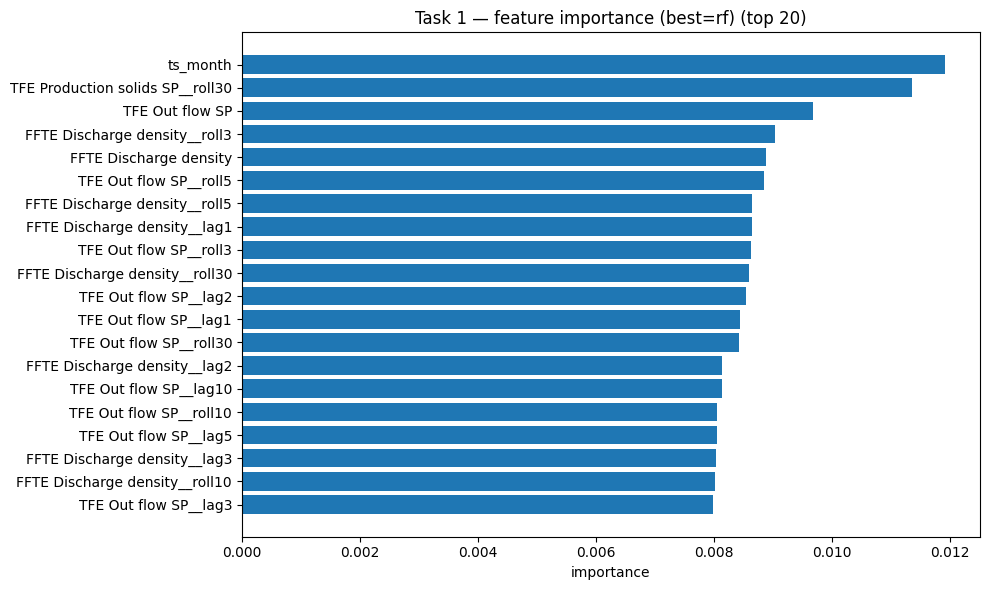


Task 2 interval — feature importance (best=cat)


,feature,importance
0,TFE Production solids PV,7.996787
1,TFE Production solids PV__roll3,6.237016
2,TFE Production solids PV__roll5,4.632425
3,TFE Motor current,3.475057
4,FFTE Production solids PV,2.401131
5,TFE Production solids PV__roll10,1.967802
6,TFE Production solids PV__lag1,1.804993
7,TFE Steam pressure PV__roll30,1.752682
8,TFE Motor current__roll5,1.554463
9,TFE Motor current__roll10,1.536201


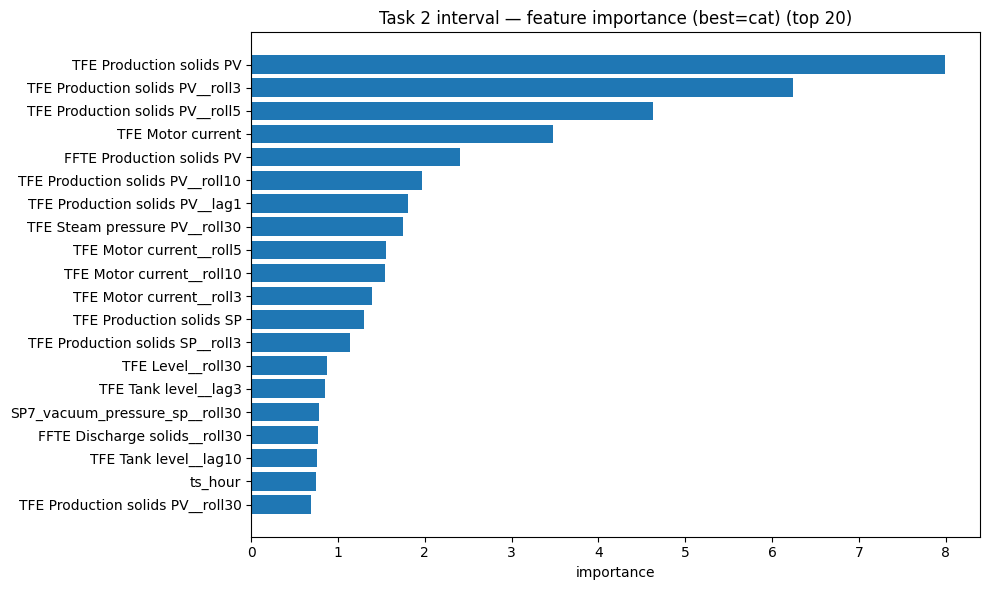


Task 2 warning — feature importance (best=cat)


,feature,importance
0,Extract tank Level,11.104151
1,Extract tank Level__roll3,7.212168
2,Extract tank Level__roll5,3.469585
3,Extract tank Level__lag1,2.711880
4,TFE Motor current__roll30,2.307443
5,TFE Production solids density__roll30,1.973175
6,Extract tank Level__lag2,1.755287
7,Extract tank Level__roll10,1.578216
8,FFTE Production solids PV,1.209632
9,TFE Tank level,1.183904


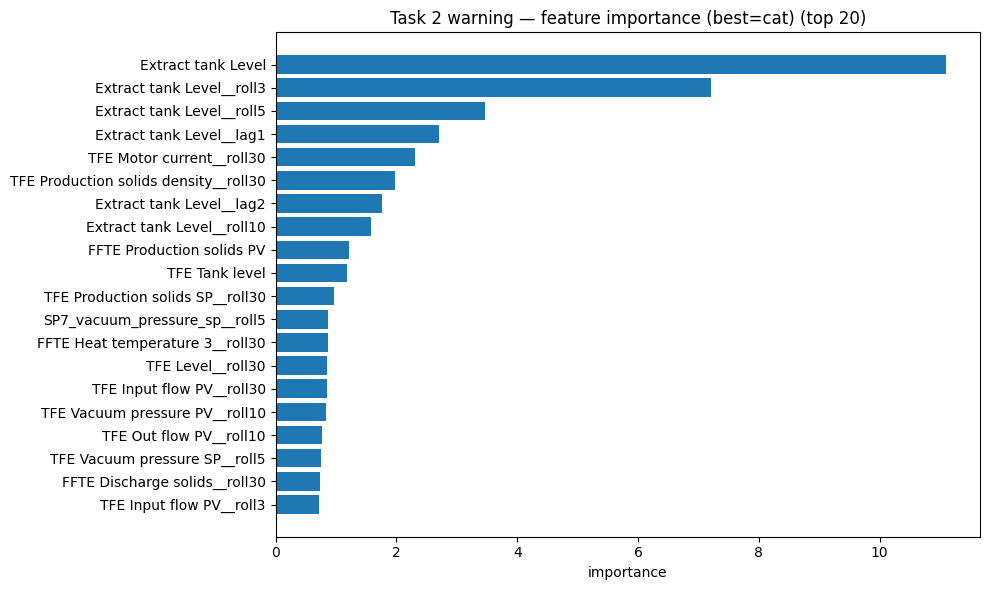

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=== Step 11: Feature Importance (best models) ===")

# Helper: extract feature importance if available

def get_feature_importance(model, feature_names):
    feature_names = list(feature_names)

    # Models with feature_importances_ (RF, LightGBM sklearn wrapper)
    if hasattr(model, "feature_importances_"):
        imp = np.asarray(model.feature_importances_, dtype=float)
        if imp.shape[0] == len(feature_names):
            return pd.DataFrame({"feature": feature_names, "importance": imp})

    # XGBoost sklearn API
    if hasattr(model, "get_booster"):
        booster = model.get_booster()
        score = booster.get_score(importance_type="gain")
        imp = np.zeros(len(feature_names), dtype=float)
        for k, v in score.items():
            if k.startswith("f"):
                idx = int(k[1:])
                if 0 <= idx < len(imp):
                    imp[idx] = float(v)
        return pd.DataFrame({"feature": feature_names, "importance": imp})

    # CatBoost
    if hasattr(model, "get_feature_importance"):
        try:
            imp = np.asarray(model.get_feature_importance(), dtype=float)
            if imp.shape[0] == len(feature_names):
                return pd.DataFrame({"feature": feature_names, "importance": imp})
        except Exception:
            pass

    return None


def show_top_importance(title, model, feature_names, top_n=20):
    df = get_feature_importance(model, feature_names)
    if df is None:
        print(title + ": no feature importance available for this model.")
        return

    df = df.sort_values("importance", ascending=False).reset_index(drop=True)
    df_top = df.head(top_n)

    print("\n" + title)
    display(df_top)

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.barh(df_top["feature"][::-1], df_top["importance"][::-1])
    ax.set_title(title + f" (top {top_n})")
    ax.set_xlabel("importance")
    plt.tight_layout()
    plt.show()


show_top_importance(
    title=f"Task 1 — feature importance (best={TASK1_BEST['name']})",
    model=m_quality,
    feature_names=TASK1_MATS["cols"],
    top_n=20,
)

show_top_importance(
    title=f"Task 2 interval — feature importance (best={TASK2_BEST_INTERVAL['name']})",
    model=m_dt_interval,
    feature_names=TASK2_MATS["cols"],
    top_n=20,
)

show_top_importance(
    title=f"Task 2 warning — feature importance (best={TASK2_BEST_WARNING['name']})",
    model=m_dt_warning,
    feature_names=TASK2_MATS["cols"],
    top_n=20,
)


---

## 12. Save Artifacts (models + configs)

Lưu toàn bộ thứ cần để reproduce inference:
- Best models (Task 1 / Task 2 interval / Task 2 warning / Task 2 where)
- Feature columns + train-only medians
- Encoders (`le_q`, `le_where`)
- Thresholds cho downtime
- Thông tin model best + val metrics

Mặc định save vào `/kaggle/working/` (nếu chạy Kaggle), nếu không thì `./output/`.


In [13]:
import os
import joblib

OUT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "./output"
os.makedirs(OUT_DIR, exist_ok=True)

# -------------------------
# Save best models (from Step 8)
# -------------------------

# Task 1: save 2-stage models
joblib.dump(TASK1_TWO_STAGE["stageA"]["model"], os.path.join(OUT_DIR, f"task1_quality_stageA_lowbad_best_{TASK1_TWO_STAGE['stageA']['name']}.joblib"))
joblib.dump(TASK1_TWO_STAGE["stageB"]["model"], os.path.join(OUT_DIR, f"task1_quality_stageB_good_vs_high_best_{TASK1_TWO_STAGE['stageB']['name']}.joblib"))

# Task 2: save best models
joblib.dump(m_dt_interval, os.path.join(OUT_DIR, f"task2_downtime_interval_best_{TASK2_BEST_INTERVAL['name']}.joblib"))
joblib.dump(m_dt_warning, os.path.join(OUT_DIR, f"task2_downtime_warning_best_{TASK2_BEST_WARNING['name']}.joblib"))
joblib.dump(m_where, os.path.join(OUT_DIR, f"task2_where_machine_best_{TASK2_BEST_WHERE['name']}.joblib"))

artifacts = {
    "random_state": RANDOM_STATE,
    "task1": {
        "best": {
            "name": "two_stage",
            "val_macro_f1": float(TASK1_TWO_STAGE["val_macro_f1"]),
        },
        "two_stage": {
            "stageA": {
                "name": TASK1_TWO_STAGE["stageA"]["name"],
                "val_F2": float(TASK1_TWO_STAGE["stageA"]["val_F2"]),
                "val_F1": float(TASK1_TWO_STAGE["stageA"]["val_F1"]),
            },
            "stageB": {
                "name": TASK1_TWO_STAGE["stageB"]["name"],
                "val_F1": float(TASK1_TWO_STAGE["stageB"]["val_f1"]),
            },
            "thr_macro": float(TASK1_TWO_STAGE["thr_macro"]),
        },
        "feature_cols": TASK1_MATS["cols"],
        "medians": TASK1_MATS["medians"],
        "label_encoder": TASK1_MATS["le_q"],
    },
    "task2": {
        "interval": {
            "best": {
                "name": TASK2_BEST_INTERVAL["name"],
                "val_f1_pos": float(TASK2_BEST_INTERVAL["val_f1_pos"]),
                "thr": float(thr_interval),
            },
        },
        "warning": {
            "best": {
                "name": TASK2_BEST_WARNING["name"],
                "val_f1_pos": float(TASK2_BEST_WARNING["val_f1_pos"]),
                "thr": float(thr_warning),
            },
        },
        "where": {
            "best": {
                "name": TASK2_BEST_WHERE["name"],
                "val_macro_f1": float(TASK2_BEST_WHERE["val_macro_f1"]),
            },
            "label_encoder": TASK2_MATS["le_where"],
        },
        "feature_cols": TASK2_MATS["cols"],
        "medians": TASK2_MATS["medians"],
    },
}

joblib.dump(artifacts, os.path.join(OUT_DIR, "theme3_stepwise_artifacts.joblib"))

print("Saved to", OUT_DIR)
print("Files:")
for fn in sorted(os.listdir(OUT_DIR)):
    if fn.endswith(".joblib") and ("task" in fn or "theme3_stepwise" in fn):
        print(" -", fn)


Saved to /kaggle/working
Files:
 - task1_quality_best_rf.joblib
 - task2_downtime_interval_best_cat.joblib
 - task2_downtime_warning_best_cat.joblib
 - task2_where_machine_best_cat.joblib
 - theme3_stepwise_artifacts.joblib
